# ESM-DMS real-data analysis (local)

Local variant of `real_data_esm_analysis.ipynb`. Runs the full workflow for the `TpoR` dataset using `facebook/esm2_t6_8M_UR50D` (6 transformer layers + embedding = 7 total).

Differences from the cluster notebook:
- Single dataset (`TpoR`) and smallest ESM2 model (`facebook/esm2_t6_8M_UR50D`).
- Embedding and inference run locally via `embed_all_sequences()` and `run_feature_inference()` — no Slurm jobs.
- `local_or_disk="both"` caches `mean_pool` and mutation-site `per_residue` embeddings to disk; inference uses `mutation_pooled`, derived from the `per_residue` cache.


In [1]:
from pathlib import Path


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from esmDMS import CellularDMSInput, ESMDMSConfig, esmDMS

REPO_ROOT = Path.cwd()
print(f"Current working directory: {REPO_ROOT}")
if not (REPO_ROOT / "esmDMS.py").exists():
    for parent in Path.cwd().parents:
        if (parent / "esmDMS.py").exists():
            REPO_ROOT = parent
            break

DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw_data"
ANALYSIS_DIR = DATA_DIR / "esm_data_analysis"
SEQUENCE_DIR = ANALYSIS_DIR / "sequence_data"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"

SEQUENCE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="darkgrid")
REPO_ROOT


/net/dali/home/barton/dhw28/.conda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current working directory: /net/dali/home/barton/dhw28/popDMS/esmDMS


PosixPath('/net/dali/home/barton/dhw28/popDMS/esmDMS')

## Dataset Registry

Single cellular dataset (`TpoR`) using a MaveDB nucleotide-count file.


In [3]:
DATASETS = {
    "TpoR": CellularDMSInput(
        reference_nuc_path=RAW_DIR / "TpoR_reference_sequence.dat",
        mavedb_csv_path=RAW_DIR / "TpoR_nucleotide_counts.csv",
    ),
}

pd.DataFrame(
    {"dataset": dataset, "kind": "cellular", "save_dir": str(SEQUENCE_DIR / dataset)}
    for dataset in DATASETS
)


,dataset,kind,save_dir
0,TpoR,cellular,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...


## Controls

`facebook/esm2_t6_8M_UR50D` has 6 transformer layers plus the initial embedding layer, giving 7 total hidden states (indices 0–6).


In [4]:
# TODO(esmDMS.py): add a public available_layers() method so notebooks do not hard-code model layers.
LAYERS = list(range(7))
REPRESENTATIVE_LAYER = 6

RAW_EMBEDDING_TYPES = ("mutation_pooled", "mean_pool", "per_residue")
EMBEDDING_TYPE = "per_residue"
RAW_CACHE_TYPES = ("mean_pool", "per_residue")

ABSTRACTION_METHOD = "Embeddings"
ABSTRACTION_PARAMS = {"norm_scheme": "none"}
NORM_SCHEME = ABSTRACTION_PARAMS["norm_scheme"]


## Create esmDMS Runner

Each dataset gets its own `esmDMS` object with a dataset-specific save directory.


In [5]:
runners = {}

for dataset, input_data in DATASETS.items():
    config = ESMDMSConfig(
        embedding_model="facebook/esm2_t6_8M_UR50D",
        embedding_method=EMBEDDING_TYPE,
        local_or_disk="both",
        save_dir=str(SEQUENCE_DIR / dataset / "local_t6"),
        dataset_name=dataset,
    )
    runners[dataset] = esmDMS(input_data=input_data, config=config)

runners


{'TpoR': <esmDMS.esmDMS at 0x7f97c85dd220>}

## Process Raw Data

Raw input parsing is handled by `esmDMS.process_raw_data()`.


In [6]:
processing_rows = []

for dataset, runner in runners.items():
    runner.process_raw_data(drop_stop_codons=True)
    df = runner.sequence_dataframe
    processing_rows.append({
        "dataset": dataset,
        "kind": "cellular",
        "rows": len(df),
        "sequence_count": df["SequenceIndex"].nunique(),
        "replicate_count": df["Replicate"].nunique(),
        "generation_count": df["Generation"].nunique(),
    })

processing_summary = pd.DataFrame(processing_rows)
processing_summary.to_csv(TABLE_DIR / "raw_processing_summary_local.csv", index=False)
processing_summary


,dataset,kind,rows,sequence_count,replicate_count,generation_count
0,TpoR,cellular,27552,2296,6,2


## Current Class Cache Status

This checks the paths that the current `esmDMS` class will use.


In [7]:
# TODO(esmDMS.py): add a public cache_status(layers, abstraction_method, norm_scheme) method.
cache_rows = []

for dataset, runner in runners.items():
    for layer in LAYERS:
        row = {
            "dataset": dataset,
            "layer": layer,
            "mean_pool_path": str(runner._embedding_path(layer, "mean_pool")),
            "mean_pool_exists": runner._embedding_path(layer, "mean_pool").exists(),
            "per_residue_path": str(runner._embedding_path(layer, "per_residue")),
            "per_residue_exists": runner._embedding_path(layer, "per_residue").exists(),
        }
        for embedding_type in RAW_EMBEDDING_TYPES:
            path = runner._inference_path(ABSTRACTION_METHOD, layer, NORM_SCHEME, embedding_type)
            row[f"{embedding_type}_inference_path"] = str(path)
            row[f"{embedding_type}_inference_exists"] = path.exists()
        cache_rows.append(row)

cache_status = pd.DataFrame(cache_rows)
cache_status.to_csv(TABLE_DIR / "current_class_cache_status_local.csv", index=False)
cache_status


,dataset,layer,mean_pool_path,mean_pool_exists,per_residue_path,per_residue_exists,mutation_pooled_inference_path,mutation_pooled_inference_exists,mean_pool_inference_path,mean_pool_inference_exists,per_residue_inference_path,per_residue_inference_exists
0,TpoR,0,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
1,TpoR,1,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
2,TpoR,2,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
3,TpoR,3,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
4,TpoR,4,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
5,TpoR,5,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False
6,TpoR,6,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False,/net/dali/home/barton/dhw28/popDMS/esmDMS/data...,False


## Embed Sequences

Runs embedding locally via `embed_all_sequences()`. This replaces the Slurm embedding batch jobs and merge step from the cluster notebook. With `local_or_disk="both"`, mutation-site `per_residue` and `mean_pool` caches are written to disk. This cell skips embedding when both cache types already exist for every layer.

> **Note:** `create_embedding_batch_job()`, `create_embedding_batch_merge_job()`, and the merge polling loop from the cluster notebook require Slurm and cannot run locally.


In [8]:
for dataset, runner in runners.items():
    cache_complete = all(
        runner._embedding_path(layer, cache_type).exists()
        for layer in LAYERS
        for cache_type in RAW_CACHE_TYPES
    )
    if cache_complete:
        print(f"Skipping {dataset}: mean_pool and per_residue caches already exist.")
        continue

    print(f"Embedding {dataset}...")
    runner.embed_all_sequences(layer="all")
    print(f"  Done.")


Embedding TpoR...


Loading weights: 100%|██████████| 102/102 [00:01<00:00, 81.43it/s]
[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

## Run Inference

Runs inference locally via `run_feature_inference()` for each layer. This replaces `create_inference_job()` and the Slurm inference array from the cluster notebook. `mutation_pooled` is derived from the saved mutation-site `per_residue` embeddings; raw `per_residue` inference treats each mutation-site residue embedding as its own residue-level population member.

> **Note:** `create_inference_job()` and `run_inference_job()` from the cluster notebook require Slurm and cannot run locally.


In [9]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        for layer in LAYERS:
            runner.run_feature_inference(
                layer=layer,
                abstraction_method=ABSTRACTION_METHOD,
                abstraction_params=ABSTRACTION_PARAMS,
                embedding_type=embedding_type,
            )


Inference: dropping 1 sequence(s) with no mutation-site features.
Inference: dropping 1 sequence(s) with no mutation-site features.
Inference: dropping 1 sequence(s) with no mutation-site features.
Inference: dropping 1 sequence(s) with no mutation-site features.
Inference: dropping 1 sequence(s) with no mutation-site features.
Inference: dropping 1 sequence(s) with no mutation-site features.
Inference: dropping 1 sequence(s) with no mutation-site features.


## Load Completed Inference Results

Results are already cached in memory from the cell above. This cell re-loads them from disk to confirm the disk cache is consistent.


In [10]:
inference_results = {}

for dataset, runner in runners.items():
    inference_results[dataset] = {}
    for embedding_type in RAW_EMBEDDING_TYPES:
        inference_results[dataset][embedding_type] = {}
        for layer in LAYERS:
            inference_results[dataset][embedding_type][layer] = runner.load_inference_results(
                layer=layer,
                abstraction_method=ABSTRACTION_METHOD,
                norm_scheme=NORM_SCHEME,
                embedding_type=embedding_type,
            )


In [11]:
inference_results.keys()


dict_keys(['TpoR'])

In [12]:
inference_results["TpoR"]["per_residue"]


{0: InferenceResult(dx=[array([-8.76267267e-03,  7.65092497e-04,  2.70202293e-02, -1.39403841e-02,
        -1.57007983e-02, -4.87878179e-03,  1.74995132e-02, -6.52193583e-03,
         1.42923729e-03, -2.01045245e-02, -7.47416775e-03, -3.57089866e-03,
         2.07095992e-02, -3.02166602e-03,  4.97017467e-03,  1.62018040e-03,
        -5.87585055e-04, -1.73907529e-02, -8.56808164e-03,  1.46644429e-02,
         1.39115605e-02,  8.23438464e-03,  8.34269137e-03, -3.20617670e-02,
         2.35487785e-02,  1.53001057e-02,  1.68583460e-02, -5.20719940e-02,
        -7.26897402e-03, -1.17450762e-02,  8.21024062e-03,  1.77379359e-02,
        -1.24008357e-03, -2.40270941e-02, -2.37684300e-02, -4.64694970e-04,
        -8.44653831e-03,  1.42698331e-02,  1.91758657e-02,  4.56800577e-03,
         2.62200258e-03, -2.13823915e-02, -1.58147056e-02, -7.14465350e-03,
         1.79903187e-02, -8.62183979e-04,  2.92628814e-02,  9.56580901e-03,
        -2.14741426e-02,  8.93651589e-03,  1.84904217e-02, -4.030

## Inference Summary

Run this after completed inference results have been loaded from the class inference cache.


In [13]:
# TODO(esmDMS.py): add an inference_summary() method that returns this table from stored results.
inference_rows = []

for dataset, embedding_results in inference_results.items():
    for embedding_type, layer_results in embedding_results.items():
        for layer, result in layer_results.items():
            inference_rows.append({
                "dataset": dataset,
                "kind": "cellular",
                "embedding_type": embedding_type,
                "layer": layer,
                "n_replicates": result.s.shape[0],
                "n_dimensions": result.s.shape[1],
                "gamma_opt": result.gamma_opt,
                "s_joint_mean": result.s_joint.mean(),
                "s_joint_std": result.s_joint.std(),
            })

inference_summary = pd.DataFrame(inference_rows)
inference_summary.to_csv(TABLE_DIR / "inference_result_summary_local.csv", index=False)
inference_summary


,dataset,kind,embedding_type,layer,n_replicates,n_dimensions,gamma_opt,s_joint_mean,s_joint_std
0,TpoR,cellular,mutation_pooled,0,6,320,0.183298,0.002750,0.043478
1,TpoR,cellular,mutation_pooled,1,6,320,0.042813,0.002946,0.121019
2,TpoR,cellular,mutation_pooled,2,6,320,0.088587,0.000649,0.077056
3,TpoR,cellular,mutation_pooled,3,6,320,0.379269,-0.000194,0.041133
4,TpoR,cellular,mutation_pooled,4,6,320,0.183298,-0.000936,0.048715
5,TpoR,cellular,mutation_pooled,5,6,320,1.623777,-0.000301,0.019811
6,TpoR,cellular,mutation_pooled,6,6,320,0.088587,-0.000587,0.098931
7,TpoR,cellular,mean_pool,0,6,320,0.010000,0.009876,0.111147
8,TpoR,cellular,mean_pool,1,6,320,0.088587,0.001434,0.071713
9,TpoR,cellular,mean_pool,2,6,320,0.088587,0.001048,0.073289


## Replicate Consistency By Layer

Layer-wise replicate consistency plots are delegated to `esmDMS.plot_avg_rep_correlations_by_layer()`.


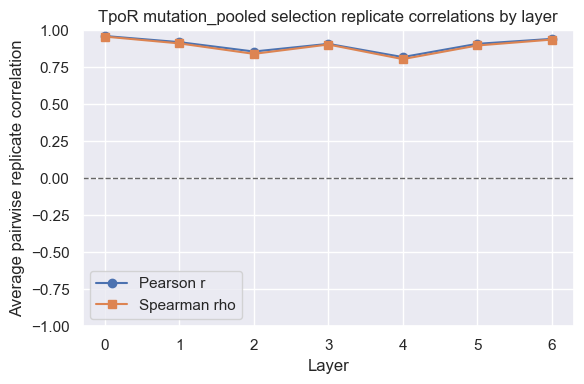

Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.


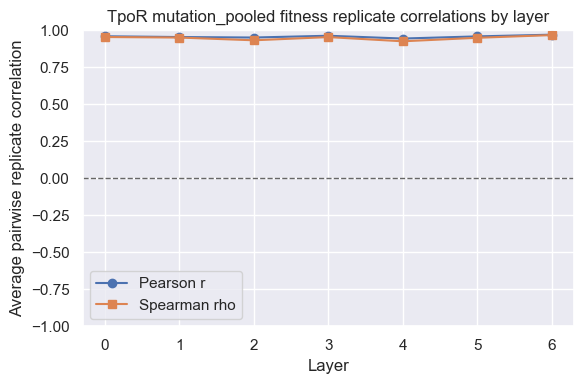

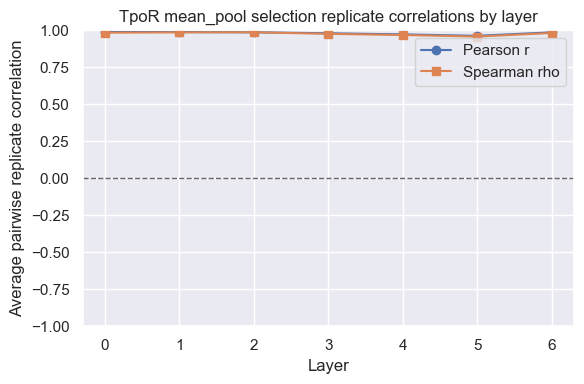

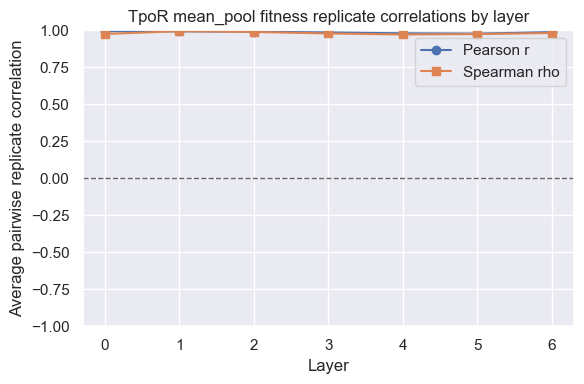

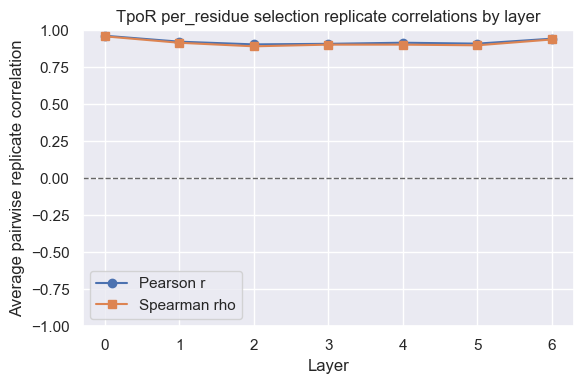

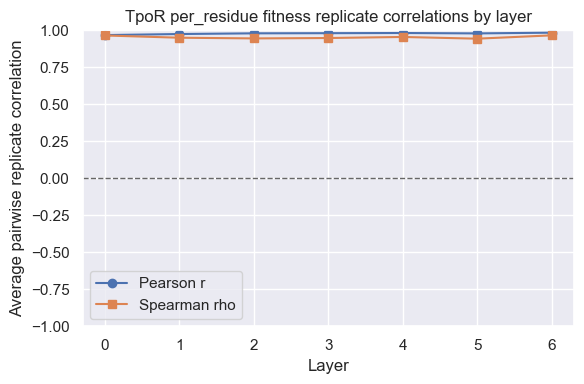

In [14]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        fig, _ = runner.plot_avg_rep_correlations_by_layer(
            layers=LAYERS,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            comparison="selection",
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)

        fig, _ = runner.plot_avg_rep_correlations_by_layer(
            layers=LAYERS,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            comparison="fitness",
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)


## Representative Replicate Scatter Plots

Replicate scatter plots are delegated to `esmDMS.plot_rep_sel_comps()` and `esmDMS.plot_rep_fit_comps()`.


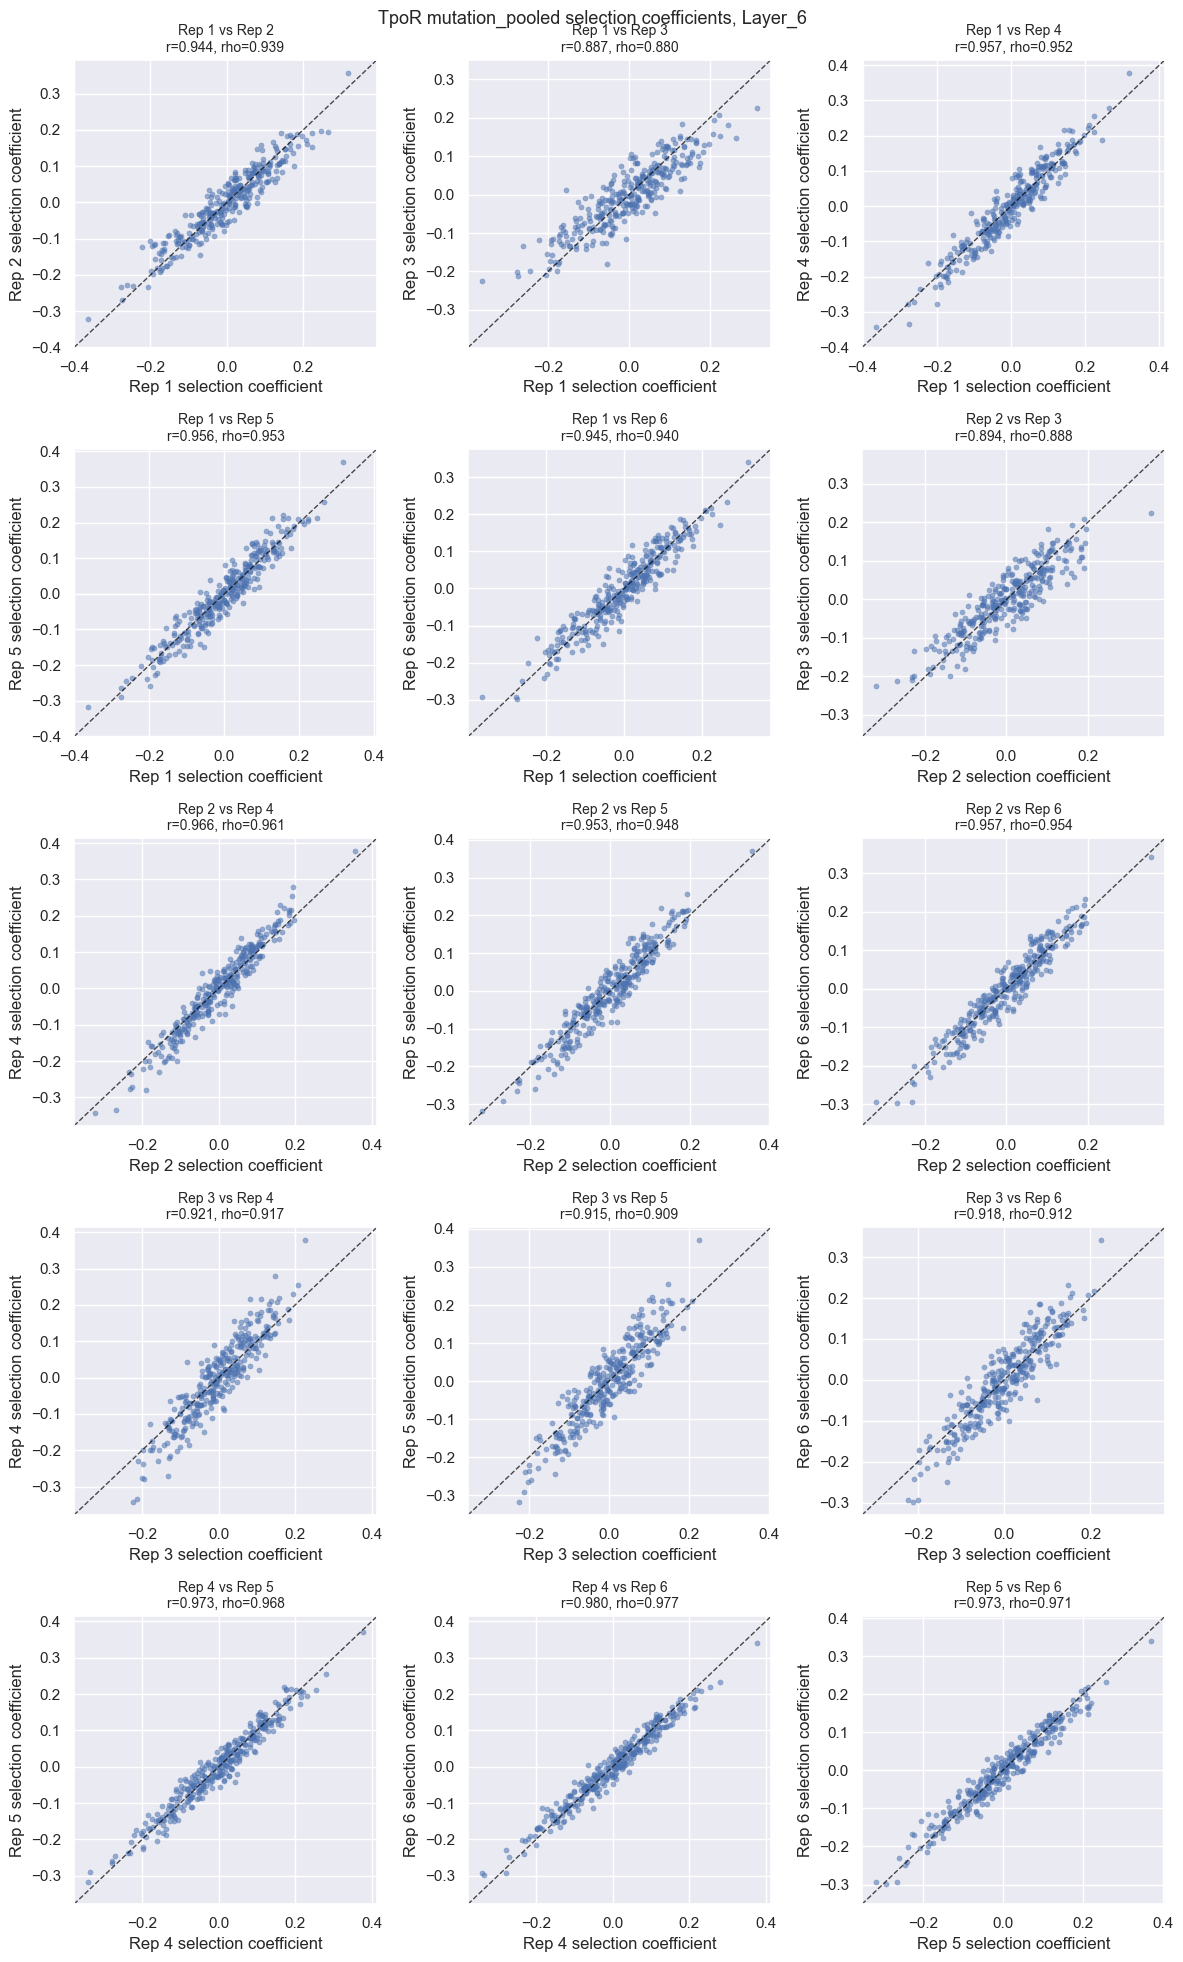

Inference plotting: dropping 1 sequence(s) with no mutation-site features.


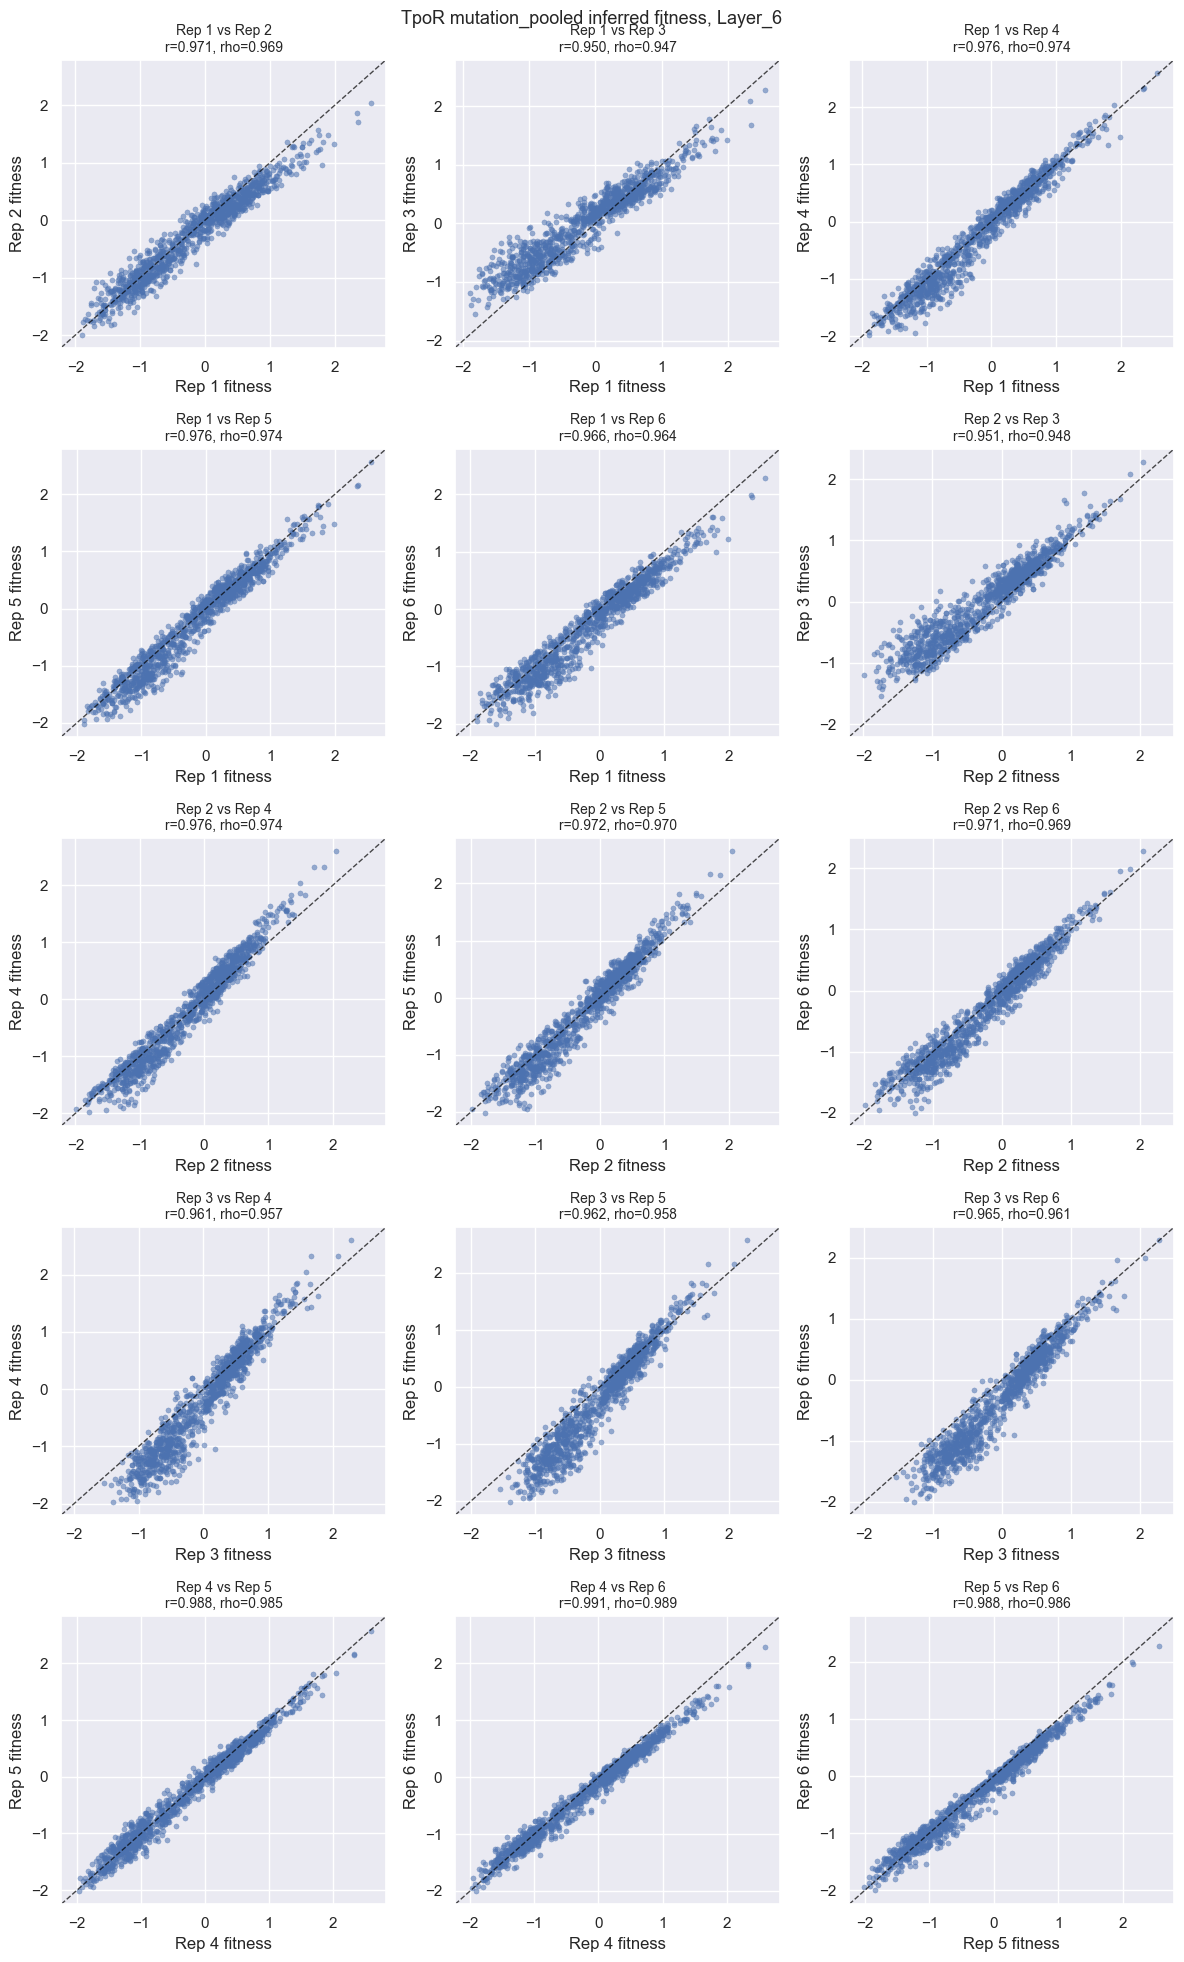

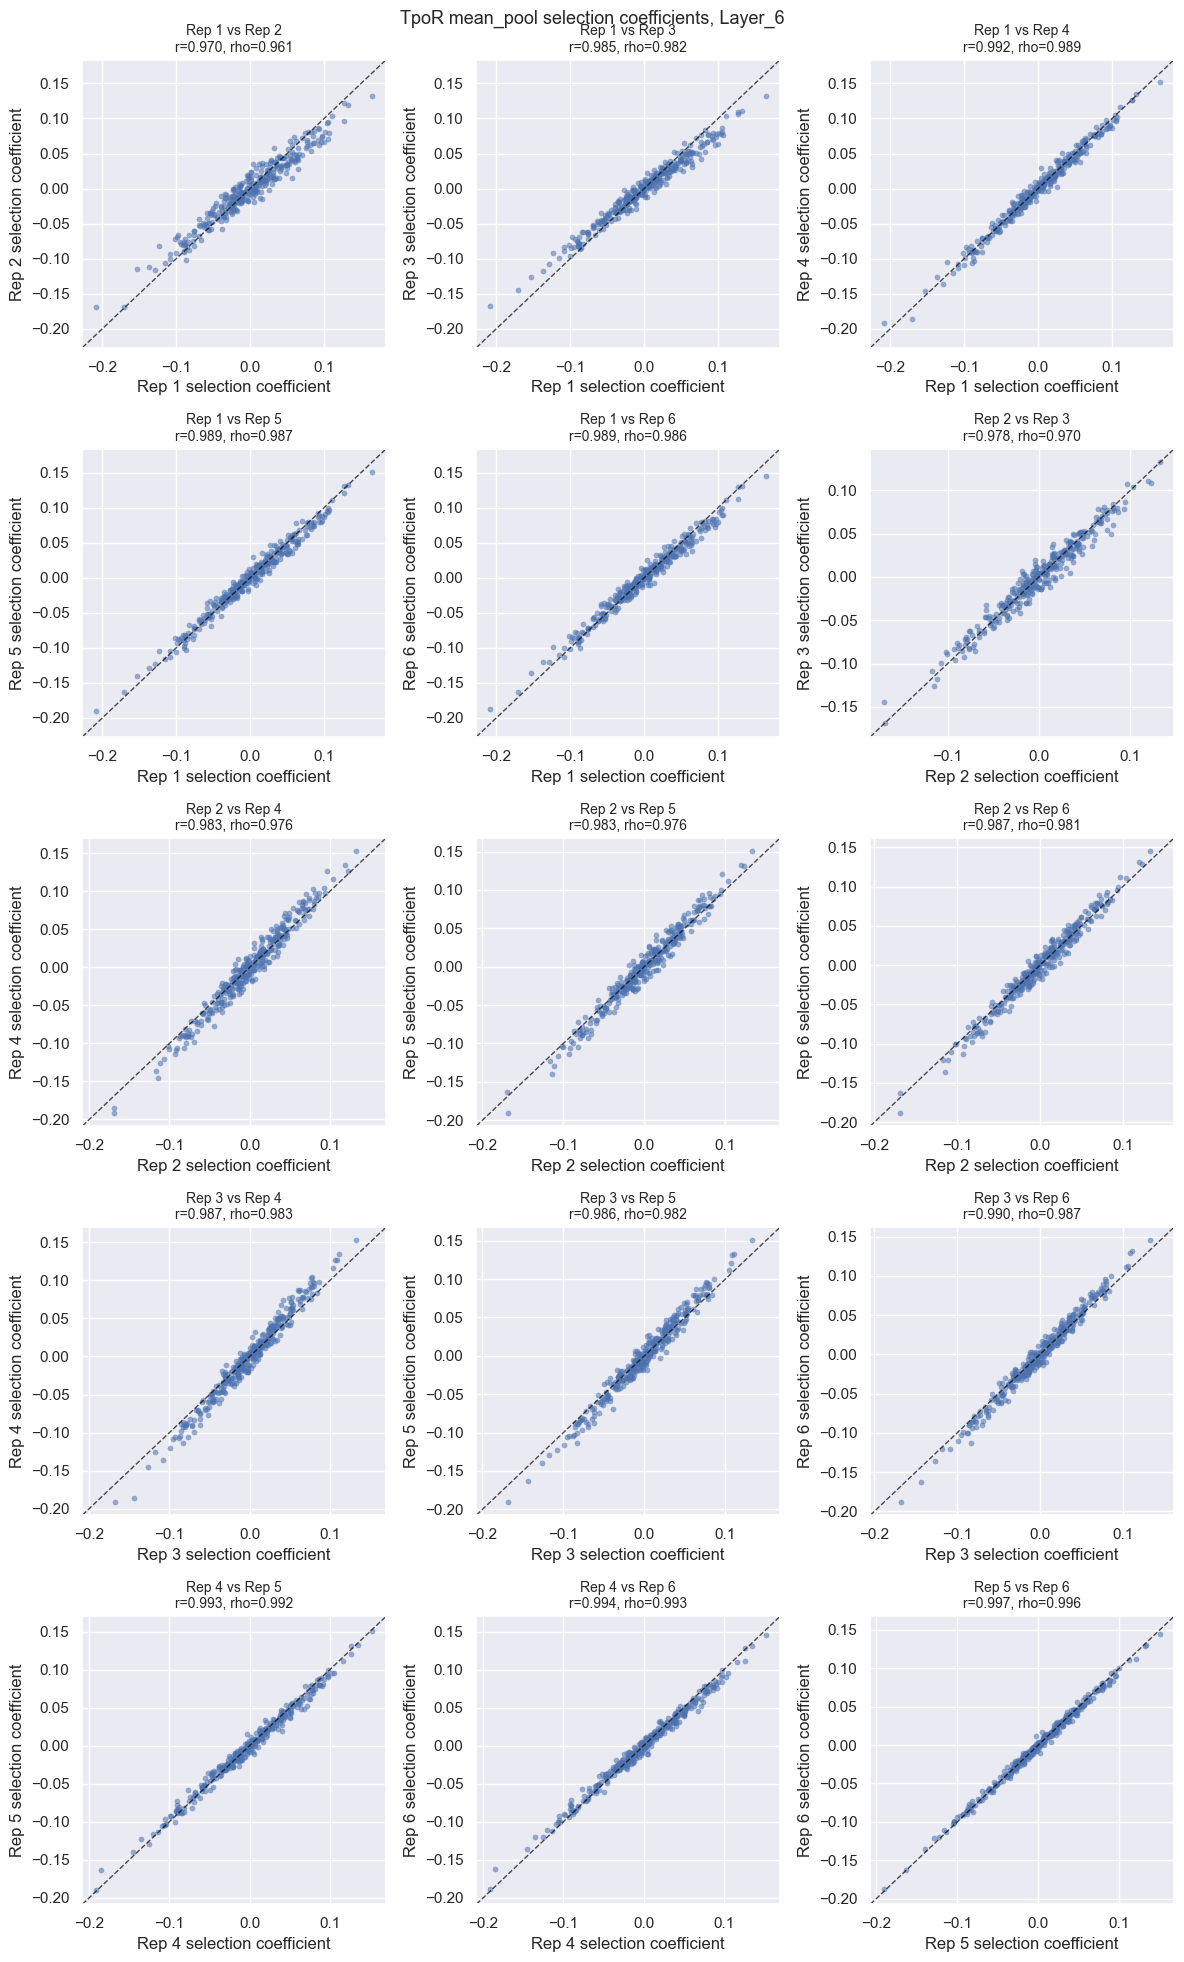

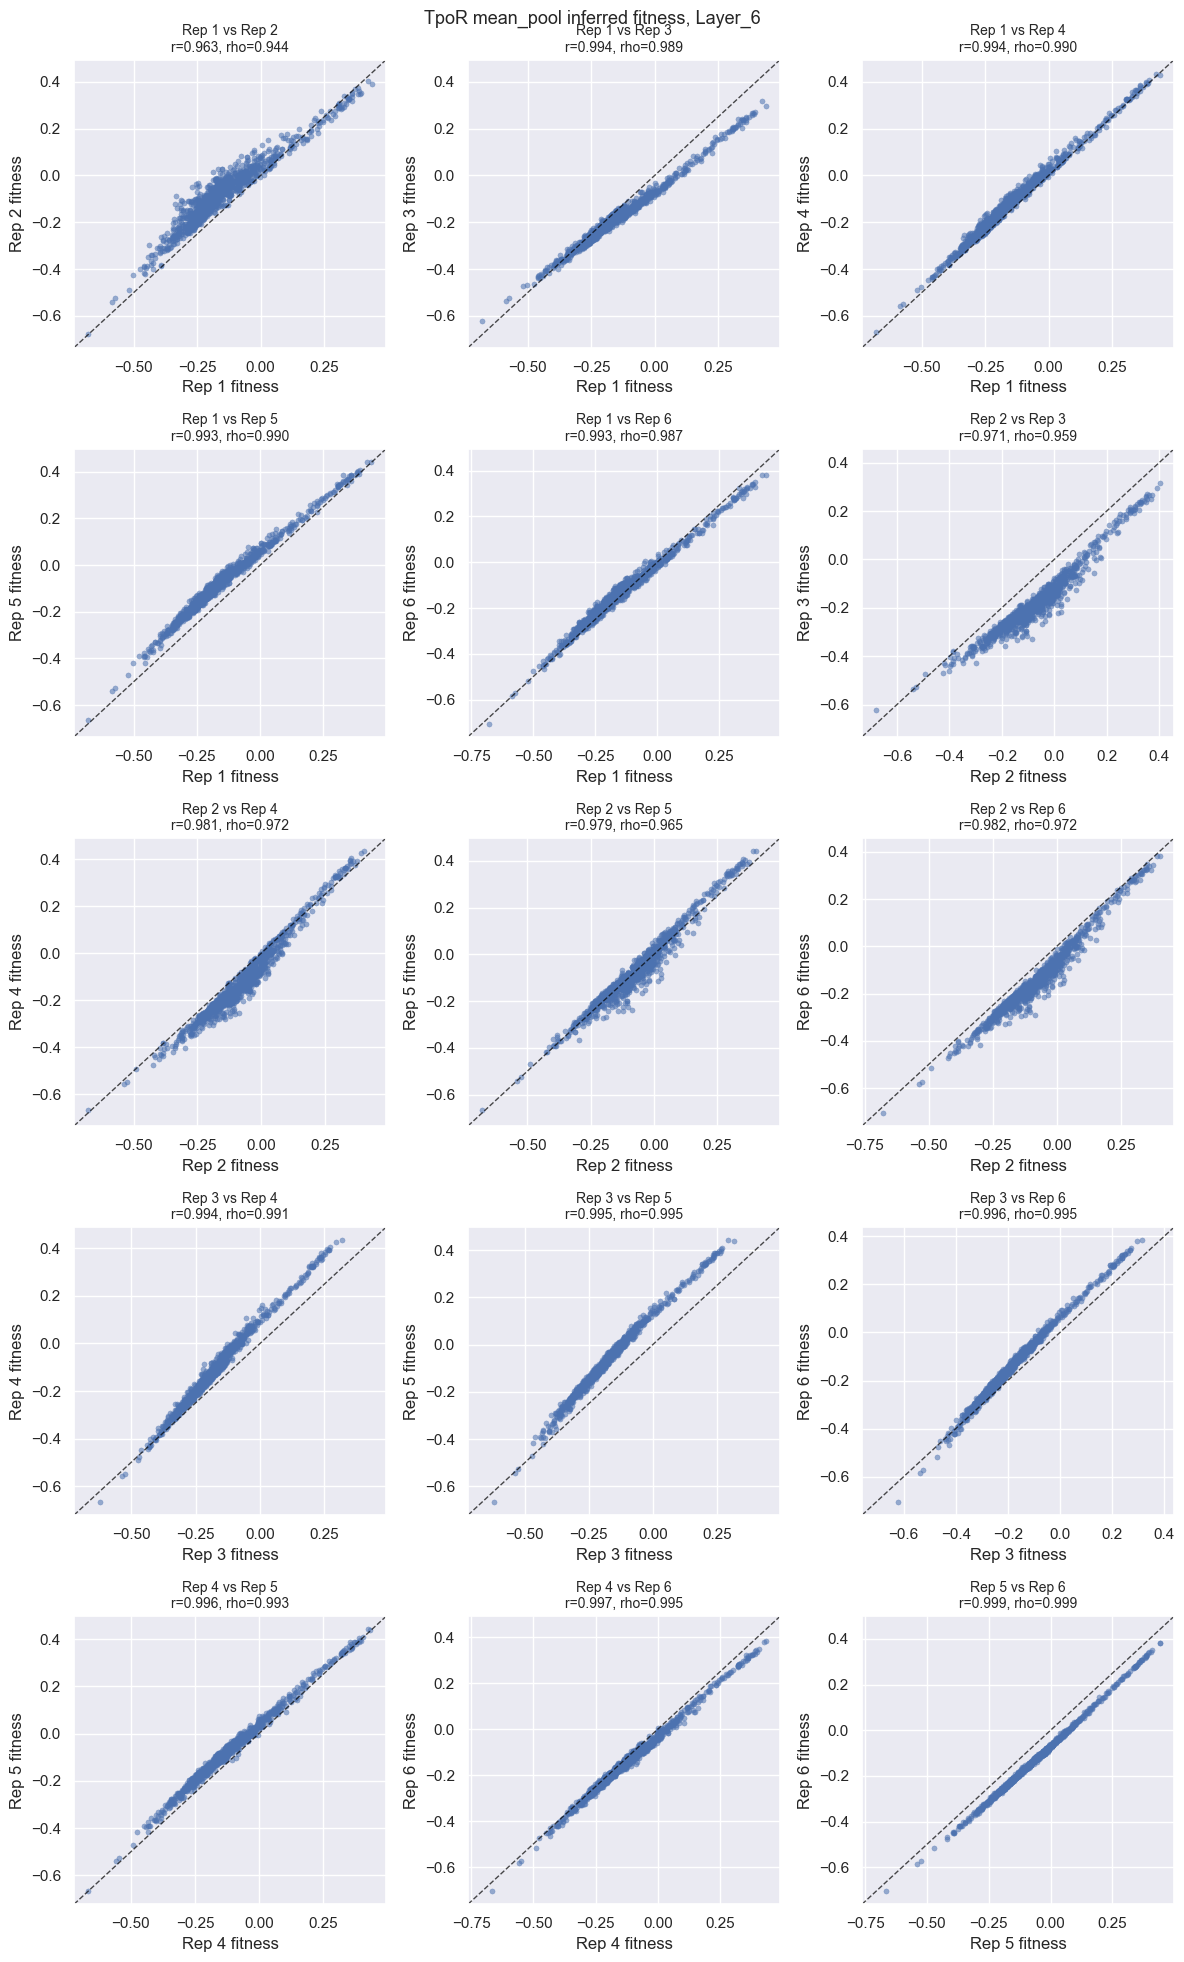

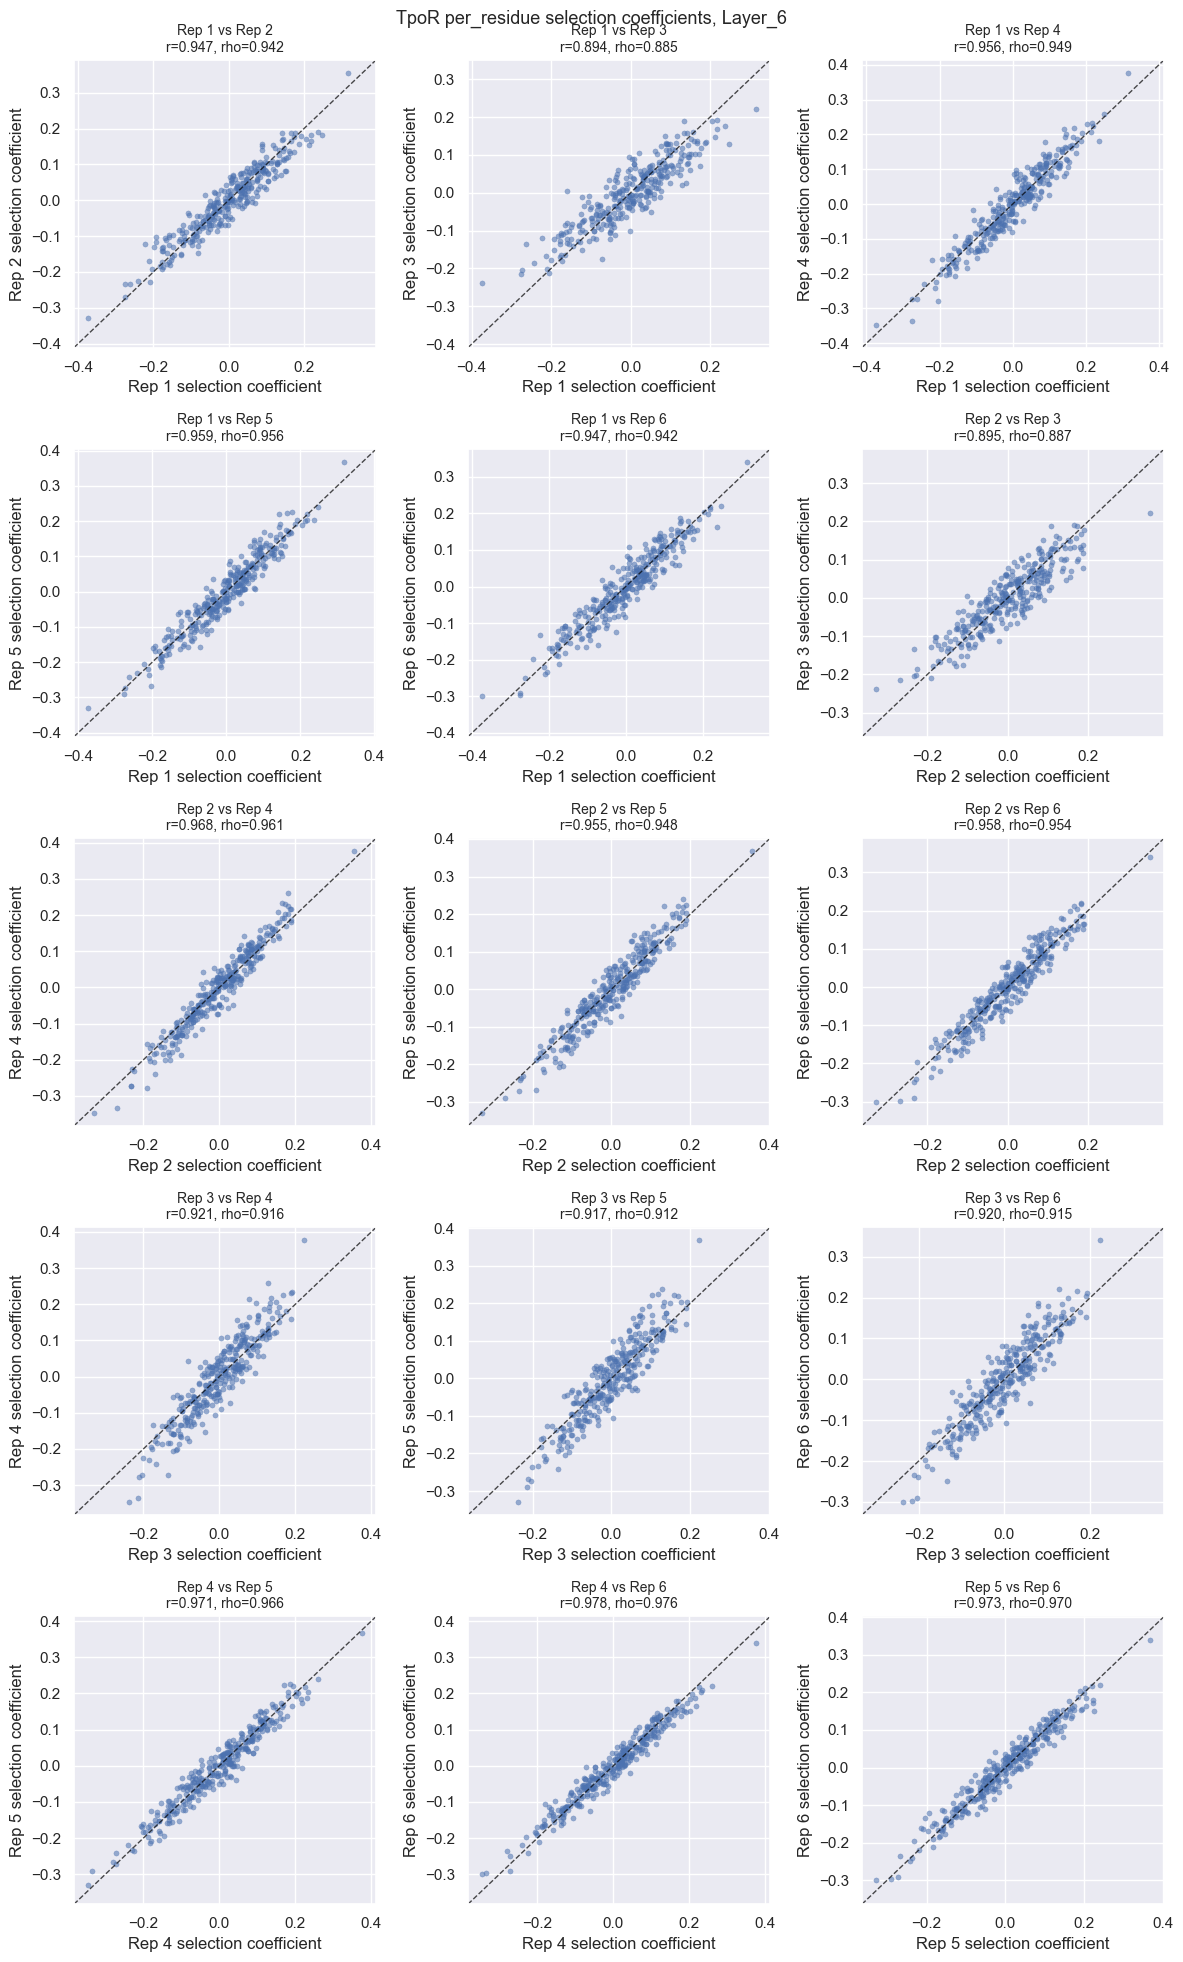

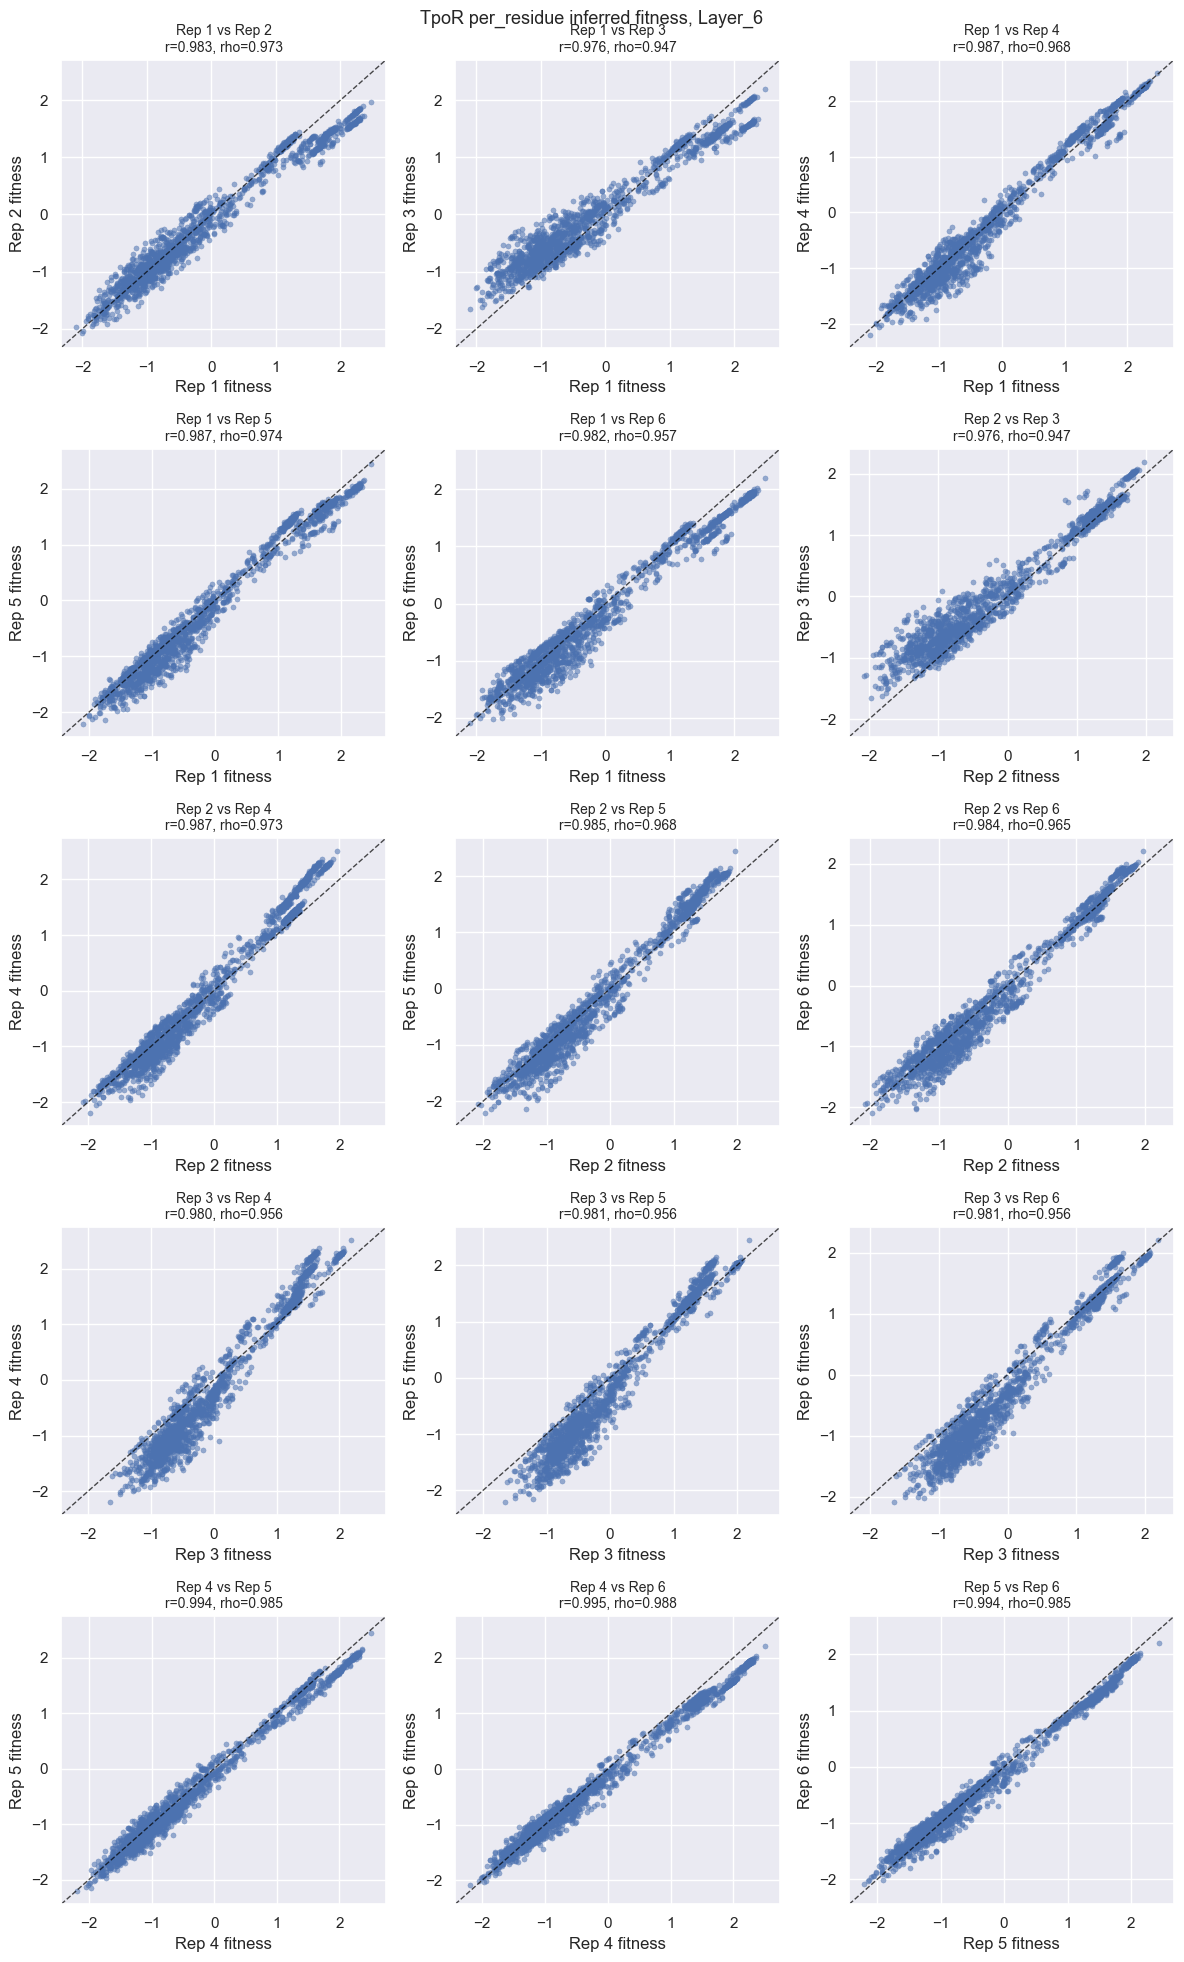

In [15]:
for dataset, runner in runners.items():
    for embedding_type in RAW_EMBEDDING_TYPES:
        fig = runner.plot_rep_sel_comps(
            layer=REPRESENTATIVE_LAYER,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)

        fig = runner.plot_rep_fit_comps(
            layer=REPRESENTATIVE_LAYER,
            abstraction_method=ABSTRACTION_METHOD,
            norm_scheme=NORM_SCHEME,
            embedding_type=embedding_type,
            label=f"{dataset} {embedding_type}",
        )
        display(fig)
        plt.close(fig)


## Sparse Autoencoder Reconstruction Sweep

Train several SAE abstractions on one representative layer, visualize reconstruction quality in the notebook, and run inference for each SAE feature space. Plots are displayed only; they are not written to disk.


Training/loading SAE_nf64_sp0p0001 for TpoR, layer 6
SAE_nf64_sp0p0001 abstraction: dropping 1 sequence(s) with no mutation-site features.
  SAE epoch 50/50  train_loss=0.00409  test_loss=0.00441
SAE: 34/64 neurons active (0 < activation frequency < 1, layer=6)
SAE model saved to /Users/dylanwells/popDMS/dylan_refactor/data/esm_data_analysis/sequence_data/TpoR/local_t6/sae_models/TpoR_per_residue_sae_Layer_6_64_0.0001_model.pt


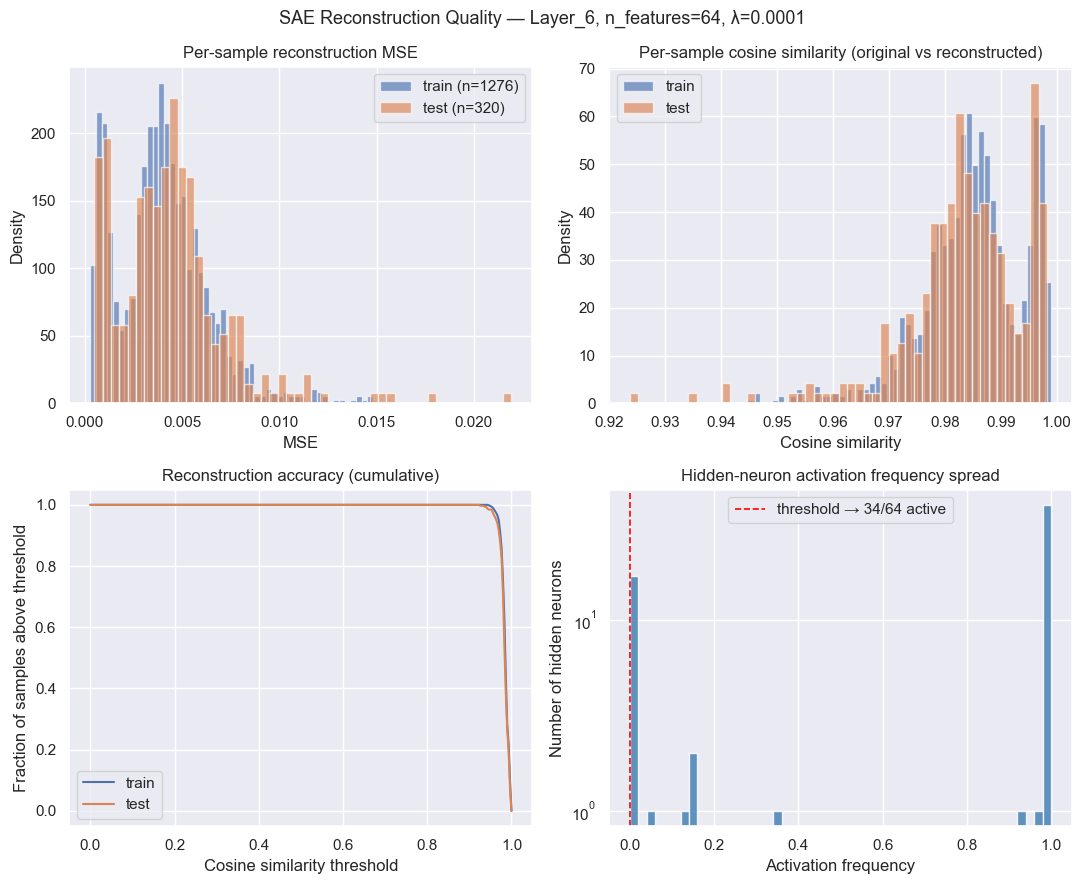

Training/loading SAE_nf128_sp0p001 for TpoR, layer 6
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
  SAE epoch 50/50  train_loss=0.00259  test_loss=0.00249
SAE: 91/128 neurons active (0 < activation frequency < 1, layer=6)
SAE model saved to /Users/dylanwells/popDMS/dylan_refactor/data/esm_data_analysis/sequence_data/TpoR/local_t6/sae_models/TpoR_per_residue_sae_Layer_6_128_0.001_model.pt


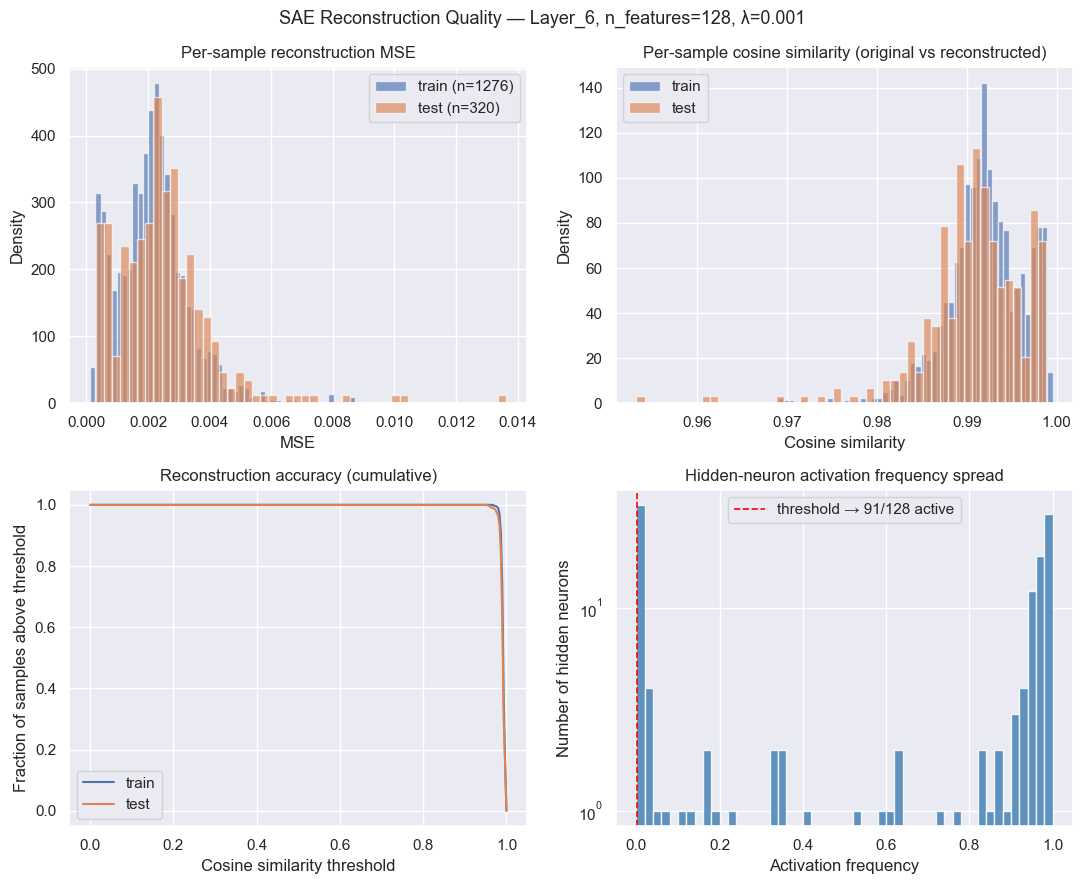

Training/loading SAE_nf256_sp0p001 for TpoR, layer 6
SAE_nf256_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
  SAE epoch 50/50  train_loss=0.00170  test_loss=0.00179
SAE: 177/256 neurons active (0 < activation frequency < 1, layer=6)
SAE model saved to /Users/dylanwells/popDMS/dylan_refactor/data/esm_data_analysis/sequence_data/TpoR/local_t6/sae_models/TpoR_per_residue_sae_Layer_6_256_0.001_model.pt


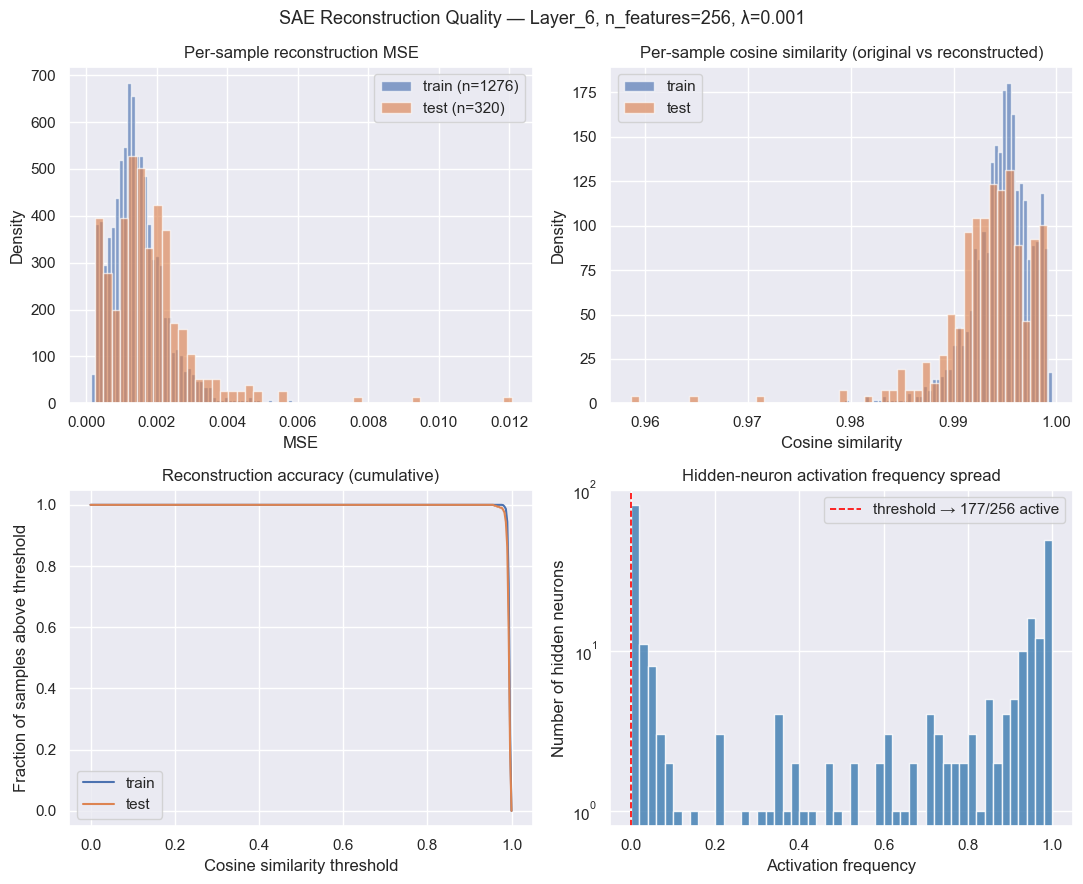

,dataset,layer,method,n_features,sparsity_coeff,epochs,batch_size
0,TpoR,6,SAE_nf64_sp0p0001,64,0.0001,50,128
1,TpoR,6,SAE_nf128_sp0p001,128,0.0010,50,128
2,TpoR,6,SAE_nf256_sp0p001,256,0.0010,50,128


In [16]:
SAE_TEST_LAYER = REPRESENTATIVE_LAYER
SAE_PARAM_GRID = [
    {"n_features": 64, "sparsity_coeff": 1e-4, "epochs": 50, "batch_size": 128},
    {"n_features": 128, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128},
    {"n_features": 256, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128},
]


def sae_method_name(params):
    sparsity = str(params["sparsity_coeff"]).replace(".", "p").replace("-", "m")
    return f"SAE_nf{params['n_features']}_sp{sparsity}"


sae_runs = []

for dataset, runner in runners.items():
    for params in SAE_PARAM_GRID:
        method = sae_method_name(params)
        sae_params = {**params, "norm_scheme": NORM_SCHEME}
        print(f"Training/loading {method} for {dataset}, layer {SAE_TEST_LAYER}")
        runner.create_feature_space(
            layer=SAE_TEST_LAYER,
            method=method,
            method_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        runner.run_feature_inference(
            layer=SAE_TEST_LAYER,
            abstraction_method=method,
            abstraction_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        fig = runner.visualize_sae_reconstructions(
            layer=SAE_TEST_LAYER,
            method_params=sae_params,
            save=False,
        )
        display(fig)
        plt.close(fig)
        sae_runs.append({
            "dataset": dataset,
            "layer": SAE_TEST_LAYER,
            "method": method,
            **params,
        })

sae_run_table = pd.DataFrame(sae_runs)
sae_run_table


## SAE Fitness Comparisons

Compare inferred sequence fitness from the raw mutation-pooled embedding model against each SAE abstraction. Each scatter plot annotates the Spearman rho between methods.


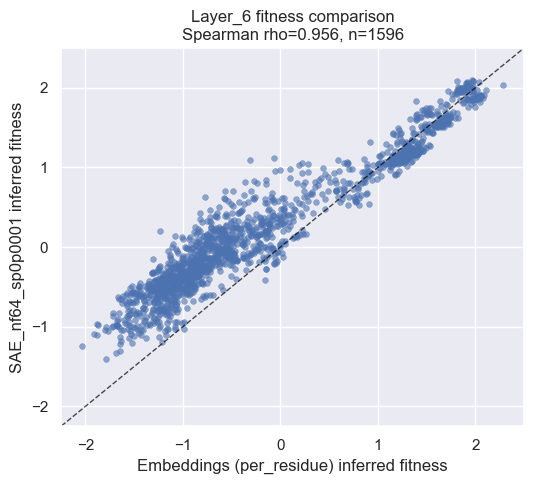

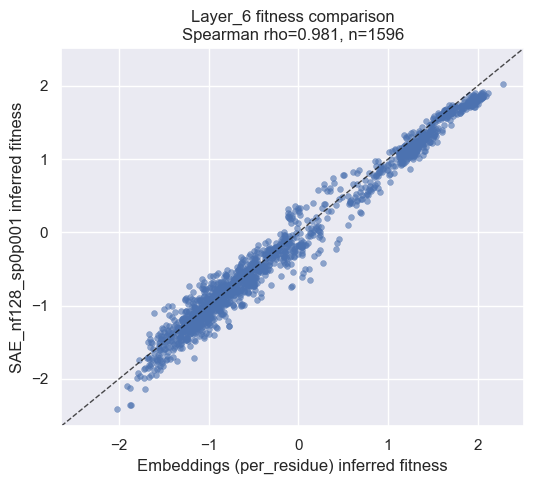

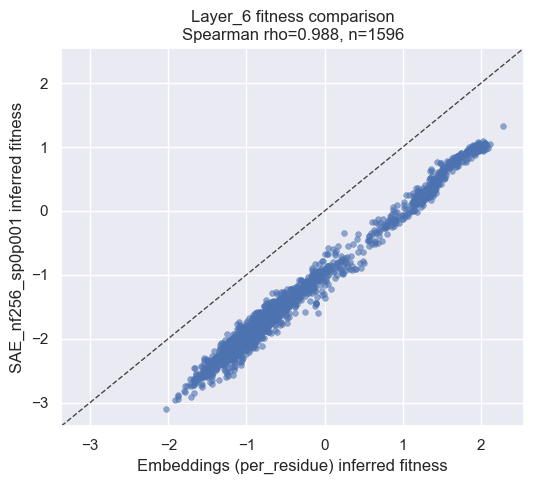

,dataset,layer,left_method,right_method,spearman_rho,n_sequences,n_features,sparsity_coeff,epochs,batch_size,norm_scheme
0,TpoR,6,none,SAE_nf64_sp0p0001,0.956087,1596,64,0.0001,50,128,none
1,TpoR,6,none,SAE_nf128_sp0p001,0.980932,1596,128,0.0010,50,128,none
2,TpoR,6,none,SAE_nf256_sp0p001,0.987769,1596,256,0.0010,50,128,none


In [17]:
sae_comparison_rows = []

for run in sae_runs:
    runner = runners[run["dataset"]]
    sae_params = {
        "n_features": run["n_features"],
        "sparsity_coeff": run["sparsity_coeff"],
        "epochs": run["epochs"],
        "batch_size": run["batch_size"],
        "norm_scheme": NORM_SCHEME,
    }
    fig, stats = runner.plot_fitness_method_comparison(
        layer=run["layer"],
        left_abstraction_method=ABSTRACTION_METHOD,
        right_abstraction_method=run["method"],
        right_abstraction_params=sae_params,
        embedding_type=EMBEDDING_TYPE,
        norm_scheme=NORM_SCHEME,
        left_label=f"{ABSTRACTION_METHOD} ({EMBEDDING_TYPE})",
        right_label=run["method"],
    )
    display(fig)
    plt.close(fig)
    sae_comparison_rows.append({"dataset": run["dataset"], **stats, **sae_params})

sae_comparison_summary = pd.DataFrame(sae_comparison_rows)
sae_comparison_summary


## SAE Fitness Correlation Across Layers

Use one SAE setting across multiple layers and plot the Spearman rho between raw mutation-pooled inferred fitness and SAE-derived inferred fitness by layer. Adjust `SAE_LAYER_SWEEP_LAYERS` or `SAE_LAYER_SWEEP_PARAMS` to control runtime.


In [18]:
SAE_LAYER_SWEEP_LAYERS = LAYERS
SAE_LAYER_SWEEP_PARAMS = {"n_features": 128, "sparsity_coeff": 1e-3, "epochs": 50, "batch_size": 128}
SAE_LAYER_SWEEP_METHOD = sae_method_name(SAE_LAYER_SWEEP_PARAMS)
SAE_LAYER_SWEEP_METHOD


'SAE_nf128_sp0p001'

SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
  SAE epoch 50/50  train_loss=0.00005  test_loss=0.00000
SAE: 127/128 neurons active (0 < activation frequency < 1, layer=0)
SAE model saved to /Users/dylanwells/popDMS/dylan_refactor/data/esm_data_analysis/sequence_data/TpoR/local_t6/sae_models/TpoR_per_residue_sae_Layer_0_128_0.001_model.pt
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
  SAE epoch 50/50  train_loss=0.00437  test_loss=0.00425
SAE: 76/128 neurons active (0 < activation frequency < 1, layer=1)
SAE model saved to /Users/dylanwells/popDMS/dylan_refactor/data/esm_data_analysis/sequence_data/TpoR/local_t6/sae_models/TpoR_per_residue_sae_Layer_1_128_0.001_model.pt
SAE_nf128_sp0p001 abstraction: dropping 1 sequence(s) with no mutation-site features.
  SAE epoch 50/50  train_loss=0.00853  test_loss=0.00944
SAE: 116/128 neurons active (0 < activation frequency < 1, layer=2)
SAE model saved to /Users/dyla

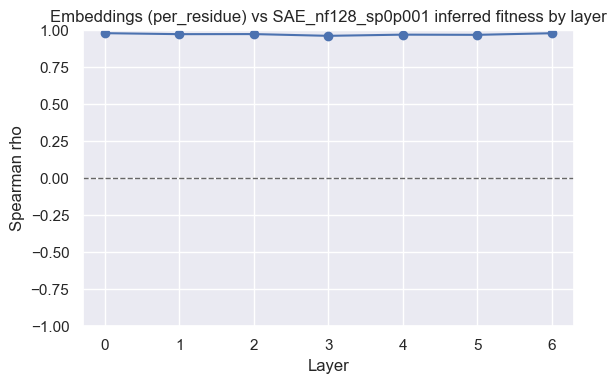

,dataset,layer,spearman_rho,n_sequences
0,TpoR,0,0.981300,1596
1,TpoR,1,0.974701,1596
2,TpoR,2,0.975193,1596
3,TpoR,3,0.963343,1596
4,TpoR,4,0.971363,1596
5,TpoR,5,0.970093,1596
6,TpoR,6,0.980932,1596


In [19]:
layer_sweep_summaries = []

for dataset, runner in runners.items():
    sae_params = {**SAE_LAYER_SWEEP_PARAMS, "norm_scheme": NORM_SCHEME}
    for layer in SAE_LAYER_SWEEP_LAYERS:
        runner.create_feature_space(
            layer=layer,
            method=SAE_LAYER_SWEEP_METHOD,
            method_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )
        runner.run_feature_inference(
            layer=layer,
            abstraction_method=SAE_LAYER_SWEEP_METHOD,
            abstraction_params=sae_params,
            embedding_type=EMBEDDING_TYPE,
        )

    fig, corr_df = runner.plot_fitness_method_correlation_by_layer(
        layers=SAE_LAYER_SWEEP_LAYERS,
        left_abstraction_method=ABSTRACTION_METHOD,
        right_abstraction_method=SAE_LAYER_SWEEP_METHOD,
        right_abstraction_params=sae_params,
        embedding_type=EMBEDDING_TYPE,
        norm_scheme=NORM_SCHEME,
        left_label=f"{ABSTRACTION_METHOD} ({EMBEDDING_TYPE})",
        right_label=SAE_LAYER_SWEEP_METHOD,
    )
    display(fig)
    plt.close(fig)
    corr_df.insert(0, "dataset", dataset)
    layer_sweep_summaries.append(corr_df)

sae_layer_sweep_summary = pd.concat(layer_sweep_summaries, ignore_index=True)
sae_layer_sweep_summary


## Method Fitness Consistency Ranking

Compare raw embedding choices and SAE abstractions by cross-replicate inferred-fitness Spearman rho. Higher mean rho means the feature space gives more consistent inferred fitness across replicate pairs.


Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.
Inference plotting: dropping 1 sequence(s) with no mutation-site features.


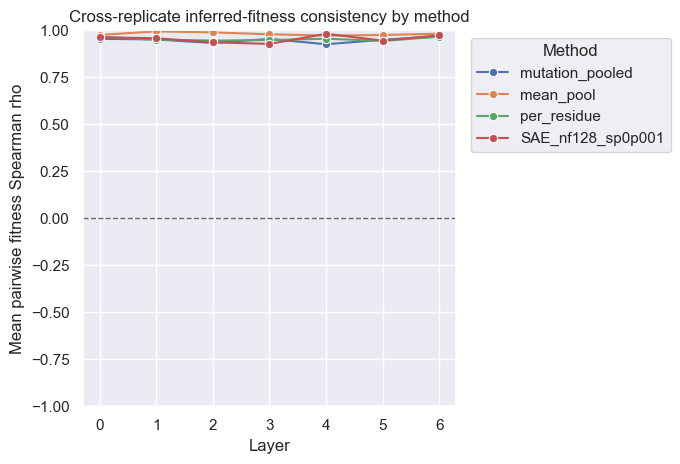

,dataset,label,layer,mean_spearman_rho,median_spearman_rho,n_pairs,n_sequences,embedding_type,abstraction_method
0,TpoR,mutation_pooled,0,0.955280,0.952393,15,1078,mutation_pooled,none
1,TpoR,mutation_pooled,1,0.951722,0.953142,15,1078,mutation_pooled,none
2,TpoR,mutation_pooled,2,0.933192,0.938069,15,1078,mutation_pooled,none
3,TpoR,mutation_pooled,3,0.954888,0.955480,15,1078,mutation_pooled,none
4,TpoR,mutation_pooled,4,0.926401,0.933840,15,1078,mutation_pooled,none
5,TpoR,mutation_pooled,5,0.950107,0.952635,15,1078,mutation_pooled,none
6,TpoR,mutation_pooled,6,0.968363,0.969035,15,1078,mutation_pooled,none
7,TpoR,mean_pool,0,0.976128,0.975639,15,1079,mean_pool,none
8,TpoR,mean_pool,1,0.994753,0.994346,15,1079,mean_pool,none
9,TpoR,mean_pool,2,0.989578,0.990062,15,1079,mean_pool,none


In [20]:
METHOD_CONSISTENCY_SPECS = [
    {
        "label": "mutation_pooled",
        "embedding_type": "mutation_pooled",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": "mean_pool",
        "embedding_type": "mean_pool",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": "per_residue",
        "embedding_type": "per_residue",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    {
        "label": SAE_LAYER_SWEEP_METHOD,
        "embedding_type": EMBEDDING_TYPE,
        "abstraction_method": SAE_LAYER_SWEEP_METHOD,
        "abstraction_params": {**SAE_LAYER_SWEEP_PARAMS, "norm_scheme": NORM_SCHEME},
    },
]

consistency_summaries = []
consistency_details = []

for dataset, runner in runners.items():
    fig, summary_df, detail_df = runner.analyze_method_fitness_consistency_by_layer(
        layers=LAYERS,
        method_specs=METHOD_CONSISTENCY_SPECS,
        norm_scheme=NORM_SCHEME,
        ensure_inference=True,
    )
    display(fig)
    plt.close(fig)
    summary_df.insert(0, "dataset", dataset)
    detail_df.insert(0, "dataset", dataset)
    consistency_summaries.append(summary_df)
    consistency_details.append(detail_df)

method_consistency_summary = pd.concat(consistency_summaries, ignore_index=True)
method_consistency_detail = pd.concat(consistency_details, ignore_index=True)
method_consistency_summary


In [21]:
method_consistency_ranking = (
    method_consistency_summary
    .groupby(["dataset", "label", "embedding_type", "abstraction_method"], as_index=False)
    .agg(
        mean_layer_rho=("mean_spearman_rho", "mean"),
        median_layer_rho=("mean_spearman_rho", "median"),
        best_layer_rho=("mean_spearman_rho", "max"),
        worst_layer_rho=("mean_spearman_rho", "min"),
        n_layers=("layer", "nunique"),
    )
    .sort_values(["dataset", "mean_layer_rho"], ascending=[True, False])
)
method_consistency_ranking


,dataset,label,embedding_type,abstraction_method,mean_layer_rho,median_layer_rho,best_layer_rho,worst_layer_rho,n_layers
1,TpoR,mean_pool,mean_pool,none,0.981448,0.979325,0.994753,0.972503,7
0,TpoR,SAE_nf128_sp0p001,per_residue,SAE_nf128_sp0p001,0.955489,0.958398,0.981889,0.928093,7
3,TpoR,per_residue,per_residue,none,0.953893,0.950585,0.966551,0.944124,7
2,TpoR,mutation_pooled,mutation_pooled,none,0.948565,0.951722,0.968363,0.926401,7


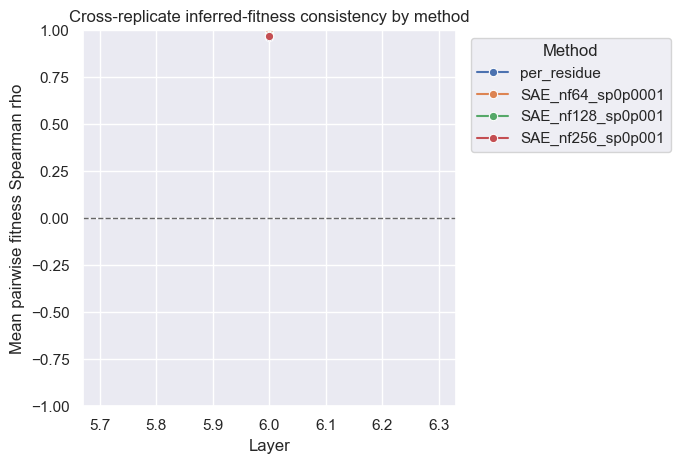

,dataset,label,layer,mean_spearman_rho,median_spearman_rho,n_pairs,n_sequences,embedding_type,abstraction_method
1,TpoR,SAE_nf64_sp0p0001,6,0.984840,0.983852,15,1596,per_residue,SAE_nf64_sp0p0001
2,TpoR,SAE_nf128_sp0p001,6,0.973918,0.972555,15,1596,per_residue,SAE_nf128_sp0p001
3,TpoR,SAE_nf256_sp0p001,6,0.972866,0.971394,15,1596,per_residue,SAE_nf256_sp0p001
0,TpoR,per_residue,6,0.966551,0.967847,15,1596,per_residue,none


In [22]:
SAE_GRID_CONSISTENCY_SPECS = [
    {
        "label": "per_residue",
        "embedding_type": "per_residue",
        "abstraction_method": ABSTRACTION_METHOD,
        "abstraction_params": ABSTRACTION_PARAMS,
    },
    *[
        {
            "label": sae_method_name(params),
            "embedding_type": EMBEDDING_TYPE,
            "abstraction_method": sae_method_name(params),
            "abstraction_params": {**params, "norm_scheme": NORM_SCHEME},
        }
        for params in SAE_PARAM_GRID
    ],
]

sae_grid_consistency_summaries = []

for dataset, runner in runners.items():
    fig, summary_df, _ = runner.analyze_method_fitness_consistency_by_layer(
        layers=[SAE_TEST_LAYER],
        method_specs=SAE_GRID_CONSISTENCY_SPECS,
        norm_scheme=NORM_SCHEME,
        ensure_inference=True,
    )
    display(fig)
    plt.close(fig)
    summary_df.insert(0, "dataset", dataset)
    sae_grid_consistency_summaries.append(summary_df)

sae_grid_consistency_summary = pd.concat(sae_grid_consistency_summaries, ignore_index=True)
sae_grid_consistency_summary.sort_values(["dataset", "mean_spearman_rho"], ascending=[True, False])


## Shuffled-Frequency Control

This notebook does not implement shuffled controls locally.


In [23]:
# TODO(esmDMS.py): add a class method for shuffled-frequency controls that shuffles
# within each (Replicate, Generation), reruns inference, and returns InferenceResult
# objects compatible with the plotting methods above.


## Sparse Autoencoder Hyperparameter Sweep

Single configurable sweep over the hyperparameters defined at the top of the next cell. Set `SAE_SWEEP_TYPE_CONFIGS`, hidden sizes, layers, embedding types, and seeds directly before running.


In [31]:
from itertools import product

import numpy as np
import torch
from scipy.stats import pearsonr, spearmanr

SAE_SWEEP_HIDDEN_SIZES = [4096, 8192]
SAE_SWEEP_LAYERS = [layer for layer in LAYERS if int(layer) >= 4]
SAE_SWEEP_EMBEDDING_TYPES = RAW_EMBEDDING_TYPES
SAE_SWEEP_TYPE_CONFIGS = [
    {"sparsity_mode": "normal", "k": None},
]
SAE_SWEEP_SEEDS = [42]
SAE_SWEEP_PRIMARY_SEED = SAE_SWEEP_SEEDS[0]
SAE_SWEEP_RUN_INFERENCE = True
SAE_SWEEP_SPARSITY_COEFF = 1e-3
SAE_SWEEP_EPOCHS = 50
SAE_SWEEP_BATCH_SIZE = 128
SAE_SWEEP_ACTIVITY_THRESHOLD = 1e-3
SAE_SWEEP_DEAD_FREQUENCY_MAX = 0.01
SAE_SWEEP_DENSE_FREQUENCY_MIN = 0.99
SAE_SWEEP_TRAIN_FRAC = 0.8
SAE_SWEEP_FORCE_RETRAIN = False
SAE_SWEEP_TIER1_KEEP_FRAC = 0.35
SAE_SWEEP_TOP_HIT_FRAC = 0.05
SAE_SWEEP_TOP_HIT_MIN_K = 10


def sae_sweep_type_label(sparsity_mode, k):
    if sparsity_mode == "normal":
        return "normal"
    return f"{sparsity_mode}_k{k}"


def sae_sweep_run_label(seed):
    return f"seed{seed}"


def sae_sweep_candidate_id(embedding_type, layer, n_features, sparsity_mode, k):
    return f"{embedding_type}|layer{layer}|hidden{n_features}|{sae_sweep_type_label(sparsity_mode, k)}"


def sae_sweep_method_name(n_features, sparsity_mode, k, seed, sparsity_coeff=SAE_SWEEP_SPARSITY_COEFF):
    sparsity = str(sparsity_coeff).replace(".", "p").replace("-", "m")
    return f"SAE_{sae_sweep_type_label(sparsity_mode, k)}_{sae_sweep_run_label(seed)}_nf{n_features}_sp{sparsity}"


def sae_sweep_params(n_features, sparsity_mode, k, seed):
    params = {
        "n_features": n_features,
        "sparsity_coeff": SAE_SWEEP_SPARSITY_COEFF,
        "epochs": SAE_SWEEP_EPOCHS,
        "batch_size": SAE_SWEEP_BATCH_SIZE,
        "train_frac": SAE_SWEEP_TRAIN_FRAC,
        "activity_threshold": SAE_SWEEP_ACTIVITY_THRESHOLD,
        "norm_scheme": NORM_SCHEME,
        "sparsity_mode": sparsity_mode,
        "seed": seed,
        "run_label": sae_sweep_run_label(seed),
    }
    if k is not None:
        params["k"] = k
    return params


def sae_sweep_viz_path(runner, layer, embedding_type, params):
    return runner._sae_viz_path(
        layer,
        params["n_features"],
        params["sparsity_coeff"],
        embedding_type,
        params.get("sparsity_mode", "normal"),
        params.get("k"),
        params.get("run_label"),
    )


def sae_sweep_model_path(runner, layer, embedding_type, params):
    return runner._sae_model_path(
        layer,
        params["n_features"],
        params["sparsity_coeff"],
        embedding_type,
        params.get("sparsity_mode", "normal"),
        params.get("k"),
        params.get("run_label"),
    )


def ensure_sae_sweep_feature_space(runner, layer, embedding_type, method, params):
    feature_path = runner._feature_path(method, layer, embedding_type)
    viz_path = sae_sweep_viz_path(runner, layer, embedding_type, params)
    if not SAE_SWEEP_FORCE_RETRAIN and feature_path.is_file() and viz_path.is_file():
        return runner._load_pickle(feature_path)

    try:
        embeddings = runner.load_embeddings(layer, embedding_type)
    except FileNotFoundError:
        print(f"Embedding missing layer cache for {embedding_type}, layer {layer}.")
        runner.embed_all_sequences(layer=layer)
        embeddings = runner.load_embeddings(layer, embedding_type)
    _, embeddings = runner._drop_missing_features(None, embeddings, f"{method} sweep")
    if embedding_type == "per_residue":
        embeddings, _ = runner._expand_per_residue_feature_vectors(
            embeddings,
            runner.sequence_to_mutation_sites,
        )
    runner._require_vector_features(embeddings, f"{method} sweep with embedding_type={embedding_type!r}")

    internal_params = dict(params)
    internal_params.setdefault("_layer", layer)
    internal_params.setdefault("_embedding_type", embedding_type)
    features = runner._create_feature_space(embeddings, method, internal_params)

    if runner._use_memory():
        runner.sequence_to_features[runner._feature_key(method, layer, embedding_type)] = features
    if runner._use_disk():
        runner._save_pickle(features, feature_path)
    return features


def normalized_entropy(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values) & (values > 0)]
    if len(values) <= 1:
        return np.nan
    p = values / values.sum()
    return float(-(p * np.log(p)).sum() / np.log(len(p)))


def reconstruction_r2(x_original, x_reconstructed, idx):
    idx = np.asarray(idx, dtype=int)
    if len(idx) == 0:
        return np.nan
    x = np.asarray(x_original)[idx]
    x_hat = np.asarray(x_reconstructed)[idx]
    sse = float(np.square(x - x_hat).sum())
    sst = float(np.square(x - x.mean(axis=0, keepdims=True)).sum())
    if sst <= 0:
        return np.nan
    return 1.0 - sse / sst


def decoder_feature_stability(model_paths):
    decoder_mats = []
    for model_path in model_paths:
        if not model_path or not Path(model_path).is_file():
            continue
        state = torch.load(model_path, map_location="cpu", weights_only=False)
        weight = state["model_state_dict"]["decoder.weight"].detach().float().numpy()
        weight = weight / np.clip(np.linalg.norm(weight, axis=0, keepdims=True), 1e-8, None)
        decoder_mats.append(weight)
    if len(decoder_mats) < 2:
        return np.nan

    scores = []
    for left_idx in range(len(decoder_mats)):
        for right_idx in range(left_idx + 1, len(decoder_mats)):
            similarity = np.abs(decoder_mats[left_idx].T @ decoder_mats[right_idx])
            scores.append(0.5 * (similarity.max(axis=0).mean() + similarity.max(axis=1).mean()))
    return float(np.nanmean(scores)) if scores else np.nan


def sae_activation_metrics(runner, layer, embedding_type, params):
    viz_path = sae_sweep_viz_path(runner, layer, embedding_type, params)
    model_path = sae_sweep_model_path(runner, layer, embedding_type, params)
    if not viz_path.is_file():
        raise FileNotFoundError(
            f"Missing SAE viz data at {viz_path}. Re-run create_feature_space for this sweep row."
        )

    viz = runner._load_pickle(viz_path)
    z_all = viz["Z_all"]
    active_mask = viz["active_mask"]
    activation_frequency = (z_all > 0).mean(axis=0)
    activation_magnitude = z_all.mean(axis=0)
    train_idx = np.asarray(viz["train_idx"], dtype=int)
    test_idx = np.asarray(viz["test_idx"], dtype=int)

    dead_mask = activation_frequency <= SAE_SWEEP_DEAD_FREQUENCY_MAX
    dense_mask = activation_frequency >= SAE_SWEEP_DENSE_FREQUENCY_MIN
    intermediate_mask = ~(dead_mask | dense_mask)

    return {
        "viz_path": str(viz_path),
        "model_path": str(model_path),
        "n_samples": z_all.shape[0],
        "n_hidden": z_all.shape[1],
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_active_features": int(active_mask.sum()),
        "active_feature_fraction": float(active_mask.mean()),
        "activation_sparsity": float((z_all <= 0).mean()),
        "activation_frequency_entropy": normalized_entropy(activation_frequency),
        "test_reconstruction_r2": reconstruction_r2(viz["X_original"], viz["X_reconstructed"], test_idx),
        "train_reconstruction_r2": reconstruction_r2(viz["X_original"], viz["X_reconstructed"], train_idx),
        "dead_threshold_max": SAE_SWEEP_DEAD_FREQUENCY_MAX,
        "dense_threshold_min": SAE_SWEEP_DENSE_FREQUENCY_MIN,
        "dead_neuron_count": int(dead_mask.sum()),
        "intermediate_neuron_count": int(intermediate_mask.sum()),
        "dense_neuron_count": int(dense_mask.sum()),
        "dead_neuron_fraction": float(dead_mask.mean()),
        "intermediate_neuron_fraction": float(intermediate_mask.mean()),
        "dense_neuron_fraction": float(dense_mask.mean()),
        "mean_activation_frequency": float(activation_frequency.mean()),
        "median_activation_frequency": float(np.median(activation_frequency)),
        "mean_activation_magnitude": float(activation_magnitude.mean()),
        "median_final_train_loss": float(np.nanmedian(viz["train_losses"][-5:])),
        "median_final_test_loss": float(np.nanmedian(viz["test_losses"][-5:])),
    }


def minmax_score(series, higher_is_better=True):
    values = series.astype(float)
    finite = np.isfinite(values)
    scores = pd.Series(np.nan, index=series.index, dtype=float)
    if finite.sum() == 0:
        return scores.fillna(0.0)
    lo = values[finite].min()
    hi = values[finite].max()
    if np.isclose(hi, lo):
        scores.loc[finite] = 1.0
    elif higher_is_better:
        scores.loc[finite] = (values[finite] - lo) / (hi - lo)
    else:
        scores.loc[finite] = (hi - values[finite]) / (hi - lo)
    return scores.fillna(scores[finite].median() if finite.any() else 0.0)


def score_tier1(summary):
    scored = summary.copy()
    scored["test_mse_score"] = minmax_score(scored["median_final_test_loss"], higher_is_better=False)
    scored["test_r2_score"] = minmax_score(scored["test_reconstruction_r2"], higher_is_better=True)
    scored["dead_feature_score"] = minmax_score(scored["dead_neuron_fraction"], higher_is_better=False)
    scored["activation_entropy_score"] = minmax_score(scored["activation_frequency_entropy"], higher_is_better=True)
    if "feature_stability" in scored:
        scored["feature_stability_score"] = minmax_score(scored["feature_stability"], higher_is_better=True)
    else:
        scored["feature_stability"] = np.nan
        scored["feature_stability_score"] = np.nan
    scored["tier1_score"] = (
        0.35 * scored["test_r2_score"]
        + 0.25 * scored["test_mse_score"]
        + 0.25 * scored["activation_entropy_score"]
        + 0.15 * scored["dead_feature_score"]
    )
    return scored


def pairwise_top_hit_overlap(rep_values, top_frac=SAE_SWEEP_TOP_HIT_FRAC, min_k=SAE_SWEEP_TOP_HIT_MIN_K):
    rep_values = np.asarray(rep_values, dtype=float)
    n_reps, n_items = rep_values.shape
    k = min(n_items, max(min_k, int(np.ceil(n_items * top_frac))))
    if n_reps < 2 or k == 0:
        return np.nan
    top_sets = []
    for values in rep_values:
        finite = np.isfinite(values)
        if finite.sum() < k:
            top_sets.append(set())
            continue
        finite_idx = np.flatnonzero(finite)
        top_idx = finite_idx[np.argsort(values[finite])[-k:]]
        top_sets.append(set(top_idx.tolist()))
    overlaps = []
    for i in range(n_reps):
        for j in range(i + 1, n_reps):
            if top_sets[i] and top_sets[j]:
                overlaps.append(len(top_sets[i] & top_sets[j]) / k)
    return float(np.nanmean(overlaps)) if overlaps else np.nan


def one_way_icc(rep_values):
    values = np.asarray(rep_values, dtype=float).T
    values = values[np.isfinite(values).all(axis=1)]
    n_targets, n_reps = values.shape if values.ndim == 2 else (0, 0)
    if n_targets < 2 or n_reps < 2:
        return np.nan
    target_means = values.mean(axis=1, keepdims=True)
    grand_mean = values.mean()
    ss_between = n_reps * np.square(target_means - grand_mean).sum()
    ss_within = np.square(values - target_means).sum()
    ms_between = ss_between / (n_targets - 1)
    ms_within = ss_within / (n_targets * (n_reps - 1))
    denom = ms_between + (n_reps - 1) * ms_within
    if denom <= 0:
        return np.nan
    return float((ms_between - ms_within) / denom)


def variant_snr(rep_values):
    rep_values = np.asarray(rep_values, dtype=float)
    mean_scores = np.nanmean(rep_values, axis=0)
    within_variant_sd = np.nanstd(rep_values, axis=0, ddof=1)
    noise = float(np.nanmedian(within_variant_sd))
    signal = float(np.nanstd(mean_scores, ddof=1))
    if noise <= 0:
        return np.nan
    return signal / noise


def tier2_replicate_metrics(runner, layer, embedding_type, method, params):
    result = runner.run_feature_inference(
        layer=layer,
        abstraction_method=method,
        abstraction_params=params,
        embedding_type=embedding_type,
    )
    _, features = runner._features_for_inference(layer, method, embedding_type, NORM_SCHEME, params)
    rep_fitness = np.asarray([features @ result.s[rep_idx] for rep_idx in range(result.s.shape[0])])

    pearson_vals = []
    spearman_vals = []
    for rep_i, rep_j in runner._rep_pairs(rep_fitness.shape[0]):
        pearson_vals.append(runner._safe_corr(rep_fitness[rep_i], rep_fitness[rep_j], pearsonr))
        spearman_vals.append(runner._safe_corr(rep_fitness[rep_i], rep_fitness[rep_j], spearmanr))

    return {
        "replicate_pearson": float(np.nanmean(pearson_vals)) if pearson_vals else np.nan,
        "replicate_spearman": float(np.nanmean(spearman_vals)) if spearman_vals else np.nan,
        "replicate_icc": one_way_icc(rep_fitness),
        "top_hit_overlap": pairwise_top_hit_overlap(rep_fitness),
        "variant_snr": variant_snr(rep_fitness),
        "n_replicates": rep_fitness.shape[0],
        "n_inference_variants": rep_fitness.shape[1],
    }


def score_tier2(summary):
    scored = summary.copy()
    scored["replicate_pearson_score"] = ((scored["replicate_pearson"].clip(-1, 1) + 1.0) / 2.0).fillna(0.0)
    scored["replicate_spearman_score"] = ((scored["replicate_spearman"].clip(-1, 1) + 1.0) / 2.0).fillna(0.0)
    scored["replicate_icc_score"] = ((scored["replicate_icc"].clip(-1, 1) + 1.0) / 2.0).fillna(0.0)
    scored["top_hit_overlap_score"] = scored["top_hit_overlap"].clip(0, 1).fillna(0.0)
    scored["variant_snr_score"] = minmax_score(scored["variant_snr"], higher_is_better=True)
    scored["tier2_score"] = (
        0.30 * scored["replicate_spearman_score"]
        + 0.25 * scored["replicate_pearson_score"]
        + 0.20 * scored["replicate_icc_score"]
        + 0.15 * scored["top_hit_overlap_score"]
        + 0.10 * scored["variant_snr_score"]
    )
    scored["overall_score"] = 0.35 * scored["tier1_score"] + 0.65 * scored["tier2_score"]
    return scored


sae_sweep_rows = []


def append_sae_sweep_row(dataset, runner, embedding_type, layer, n_features, type_config, seed):
    sparsity_mode = type_config["sparsity_mode"]
    k = type_config["k"]
    params = sae_sweep_params(n_features, sparsity_mode, k, seed)
    method = sae_sweep_method_name(n_features, sparsity_mode, k, seed, SAE_SWEEP_SPARSITY_COEFF)
    sae_type = sae_sweep_type_label(sparsity_mode, k)
    candidate_id = sae_sweep_candidate_id(embedding_type, layer, n_features, sparsity_mode, k)
    print(
        f"SAE sweep: {dataset} | {embedding_type} | layer {layer} | "
        f"hidden {n_features} | type {sae_type} | seed {seed}"
    )
    ensure_sae_sweep_feature_space(runner, layer, embedding_type, method, params)
    metrics = sae_activation_metrics(runner, layer, embedding_type, params)
    sae_sweep_rows.append({
        "dataset": dataset,
        "candidate_id": candidate_id,
        "embedding_type": embedding_type,
        "layer": layer,
        "method": method,
        "sae_type": sae_type,
        "sparsity_mode": sparsity_mode,
        "k": k,
        "seed": seed,
        "n_features": n_features,
        "sparsity_coeff": SAE_SWEEP_SPARSITY_COEFF,
        "epochs": SAE_SWEEP_EPOCHS,
        "batch_size": SAE_SWEEP_BATCH_SIZE,
        **metrics,
    })


def summarize_tier1(rows):
    summary = pd.DataFrame(rows)
    if summary.empty:
        return summary

    aggregate_metrics = {
        "n_samples": "mean",
        "n_hidden": "mean",
        "n_train": "mean",
        "n_test": "mean",
        "n_active_features": "mean",
        "active_feature_fraction": "mean",
        "activation_sparsity": "mean",
        "activation_frequency_entropy": "mean",
        "test_reconstruction_r2": "mean",
        "train_reconstruction_r2": "mean",
        "dead_neuron_count": "mean",
        "intermediate_neuron_count": "mean",
        "dense_neuron_count": "mean",
        "dead_neuron_fraction": "mean",
        "intermediate_neuron_fraction": "mean",
        "dense_neuron_fraction": "mean",
        "mean_activation_frequency": "mean",
        "median_activation_frequency": "mean",
        "mean_activation_magnitude": "mean",
        "median_final_train_loss": "mean",
        "median_final_test_loss": "mean",
    }

    grouped = (
        summary
        .groupby([
            "dataset",
            "candidate_id",
            "embedding_type",
            "layer",
            "sae_type",
            "sparsity_mode",
            "k",
            "n_features",
            "sparsity_coeff",
            "epochs",
            "batch_size",
        ], dropna=False)
        .agg(aggregate_metrics | {"seed": "nunique"})
        .rename(columns={"seed": "n_seeds"})
        .reset_index()
    )

    if len(SAE_SWEEP_SEEDS) > 1:
        stability_by_candidate = (
            summary
            .groupby(["dataset", "candidate_id"], dropna=False)["model_path"]
            .apply(lambda paths: decoder_feature_stability(list(paths)))
            .rename("feature_stability")
            .reset_index()
        )
        grouped = grouped.merge(stability_by_candidate, on=["dataset", "candidate_id"], how="left")
    else:
        grouped["feature_stability"] = np.nan

    return score_tier1(grouped)


for dataset, runner in runners.items():
    for embedding_type, layer, n_features, type_config, seed in product(
        SAE_SWEEP_EMBEDDING_TYPES,
        SAE_SWEEP_LAYERS,
        SAE_SWEEP_HIDDEN_SIZES,
        SAE_SWEEP_TYPE_CONFIGS,
        SAE_SWEEP_SEEDS,
    ):
        append_sae_sweep_row(
            dataset,
            runner,
            embedding_type,
            layer,
            n_features,
            type_config,
            seed,
        )

sae_sweep_summary = pd.DataFrame(sae_sweep_rows)
sae_sweep_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_per_seed_summary.csv", index=False)

sae_sweep_tier1_summary = summarize_tier1(sae_sweep_rows)
sae_sweep_tier1_summary["tier1_rank"] = sae_sweep_tier1_summary["tier1_score"].rank(ascending=False, method="min")
sae_sweep_tier1_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_tier1_scores.csv", index=False)

sae_sweep_tier2_rows = []
if SAE_SWEEP_RUN_INFERENCE:
    primary_seed_rows = sae_sweep_summary[sae_sweep_summary["seed"] == SAE_SWEEP_PRIMARY_SEED]
    for _, seed_row in primary_seed_rows.iterrows():
        runner = runners[seed_row["dataset"]]
        params = sae_sweep_params(
            int(seed_row["n_features"]),
            seed_row["sparsity_mode"],
            None if pd.isna(seed_row["k"]) else int(seed_row["k"]),
            SAE_SWEEP_PRIMARY_SEED,
        )
        print(
            f"Inference scoring: {seed_row['dataset']} | {seed_row['embedding_type']} | "
            f"layer {seed_row['layer']} | hidden {seed_row['n_features']} | type {seed_row['sae_type']}"
        )
        tier2_metrics = tier2_replicate_metrics(
            runner,
            seed_row["layer"],
            seed_row["embedding_type"],
            seed_row["method"],
            params,
        )
        sae_sweep_tier2_rows.append({
            "dataset": seed_row["dataset"],
            "candidate_id": seed_row["candidate_id"],
            "primary_seed_method": seed_row["method"],
            "primary_seed": SAE_SWEEP_PRIMARY_SEED,
            **tier2_metrics,
        })

sae_sweep_tier2_summary = pd.DataFrame(sae_sweep_tier2_rows)
if not sae_sweep_tier2_summary.empty:
    sae_sweep_scored_summary = score_tier2(
        sae_sweep_tier1_summary.merge(
            sae_sweep_tier2_summary,
            on=["dataset", "candidate_id"],
            how="left",
        )
    )
else:
    sae_sweep_scored_summary = sae_sweep_tier1_summary.copy()
    sae_sweep_scored_summary["overall_score"] = sae_sweep_scored_summary["tier1_score"]

sae_sweep_tier2_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_tier2_replicate_scores.csv", index=False)
sae_sweep_scored_summary.to_csv(TABLE_DIR / "sae_hyperparameter_sweep_scored_summary.csv", index=False)
sae_sweep_scored_summary.sort_values(["overall_score", "tier1_score"], ascending=[False, False])


SAE sweep: TpoR | mutation_pooled | layer 4 | hidden 4096 | type normal | seed 42
SAE sweep: TpoR | mutation_pooled | layer 4 | hidden 8192 | type normal | seed 42
SAE sweep: TpoR | mutation_pooled | layer 5 | hidden 4096 | type normal | seed 42
SAE sweep: TpoR | mutation_pooled | layer 5 | hidden 8192 | type normal | seed 42
SAE sweep: TpoR | mutation_pooled | layer 6 | hidden 4096 | type normal | seed 42
SAE sweep: TpoR | mutation_pooled | layer 6 | hidden 8192 | type normal | seed 42
SAE sweep: TpoR | mean_pool | layer 4 | hidden 4096 | type normal | seed 42
SAE sweep: TpoR | mean_pool | layer 4 | hidden 8192 | type normal | seed 42
SAE sweep: TpoR | mean_pool | layer 5 | hidden 4096 | type normal | seed 42
SAE sweep: TpoR | mean_pool | layer 5 | hidden 8192 | type normal | seed 42
SAE sweep: TpoR | mean_pool | layer 6 | hidden 4096 | type normal | seed 42
SAE sweep: TpoR | mean_pool | layer 6 | hidden 8192 | type normal | seed 42
SAE sweep: TpoR | per_residue | layer 4 | hidden 409

,dataset,candidate_id,embedding_type,layer,sae_type,sparsity_mode,k,n_features,sparsity_coeff,epochs,...,variant_snr,n_replicates,n_inference_variants,replicate_pearson_score,replicate_spearman_score,replicate_icc_score,top_hit_overlap_score,variant_snr_score,tier2_score,overall_score
17,TpoR,per_residue|layer6|hidden8192|normal,per_residue,6,normal,normal,NaN,8192,0.001,50,...,5.939828,6,1596,0.989335,0.963911,0.982813,0.835000,0.690768,0.927397,0.870762
16,TpoR,per_residue|layer6|hidden4096|normal,per_residue,6,normal,normal,NaN,4096,0.001,50,...,5.416854,6,1596,0.989054,0.965471,0.977926,0.855833,0.585214,0.919386,0.866764
12,TpoR,per_residue|layer4|hidden4096|normal,per_residue,4,normal,normal,NaN,4096,0.001,50,...,5.745265,6,1596,0.992583,0.980232,0.983517,0.763333,0.651498,0.918568,0.857651
4,TpoR,mean_pool|layer6|hidden4096|normal,mean_pool,6,normal,normal,NaN,4096,0.001,50,...,5.962620,6,1079,0.992545,0.991020,0.983486,0.966667,0.695368,0.956676,0.856359
5,TpoR,mean_pool|layer6|hidden8192|normal,mean_pool,6,normal,normal,NaN,8192,0.001,50,...,7.471931,6,1079,0.992406,0.990819,0.988189,0.961728,1.000000,0.987244,0.847521
13,TpoR,per_residue|layer4|hidden8192|normal,per_residue,4,normal,normal,NaN,8192,0.001,50,...,4.681867,6,1596,0.992302,0.979341,0.974633,0.813333,0.436867,0.902491,0.836895
0,TpoR,mean_pool|layer4|hidden4096|normal,mean_pool,4,normal,normal,NaN,4096,0.001,50,...,5.041629,6,1079,0.991177,0.988325,0.976852,0.949383,0.509480,0.933018,0.832705
6,TpoR,mutation_pooled|layer4|hidden4096|normal,mutation_pooled,4,normal,normal,NaN,4096,0.001,50,...,3.873252,6,1078,0.985938,0.983376,0.965186,0.887654,0.273661,0.895049,0.827298
11,TpoR,mutation_pooled|layer6|hidden8192|normal,mutation_pooled,6,normal,normal,NaN,8192,0.001,50,...,4.403232,6,1078,0.978962,0.971144,0.967144,0.818519,0.380629,0.890353,0.816088
10,TpoR,mutation_pooled|layer6|hidden4096|normal,mutation_pooled,6,normal,normal,NaN,4096,0.001,50,...,3.732521,6,1078,0.979634,0.972660,0.956505,0.808642,0.245256,0.873829,0.813167


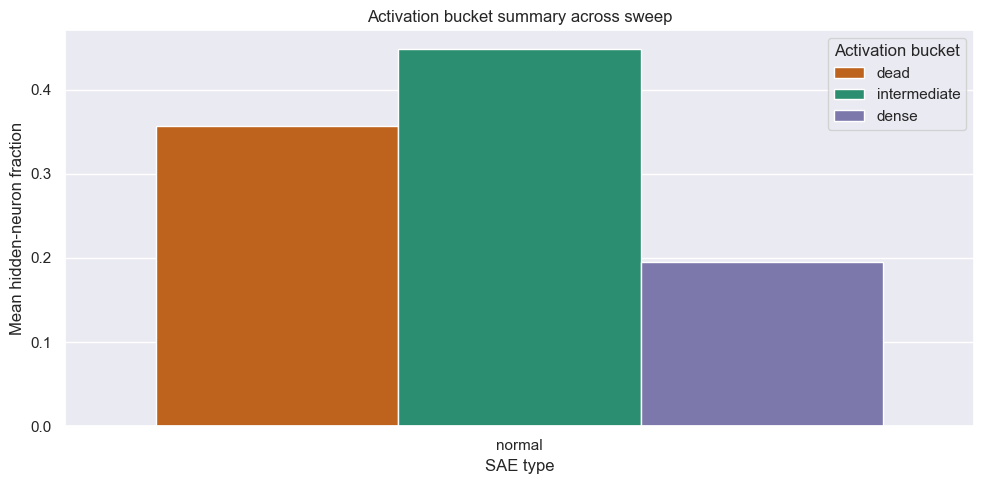

,dataset,embedding_type,layer,n_features,sae_type,overall_score,tier1_score,test_reconstruction_r2,median_final_test_loss,activation_frequency_entropy,dead_neuron_fraction,intermediate_neuron_fraction,dense_neuron_fraction,tier2_score,replicate_spearman,replicate_pearson,replicate_icc,top_hit_overlap,variant_snr
0,TpoR,per_residue,6,8192,normal,0.870762,0.765585,0.584121,0.012510,0.950355,0.189453,0.735840,0.074707,0.927397,0.927822,0.978670,0.965626,0.835000,5.939828
1,TpoR,per_residue,6,4096,normal,0.866764,0.769038,0.780321,0.006653,0.943423,0.194824,0.732666,0.072510,0.919386,0.930942,0.978108,0.955852,0.855833,5.416854
2,TpoR,per_residue,4,4096,normal,0.857651,0.744520,0.777668,0.106163,0.955760,0.317871,0.528320,0.153809,0.918568,0.960463,0.985165,0.967034,0.763333,5.745265
3,TpoR,mean_pool,6,4096,normal,0.856359,0.670057,0.178693,0.000737,0.976479,0.597656,0.101318,0.301025,0.956676,0.982039,0.985091,0.966972,0.966667,5.962620
4,TpoR,mean_pool,6,8192,normal,0.847521,0.588035,-0.432762,0.001306,0.980289,0.561035,0.109619,0.329346,0.987244,0.981639,0.984811,0.976378,0.961728,7.471931
5,TpoR,per_residue,4,8192,normal,0.836895,0.715073,0.595544,0.192594,0.961827,0.295410,0.535889,0.168701,0.902491,0.958682,0.984605,0.949265,0.813333,4.681867
6,TpoR,mean_pool,4,4096,normal,0.832705,0.646410,-0.225269,0.013309,0.987143,0.583984,0.055664,0.360352,0.933018,0.976651,0.982354,0.953704,0.949383,5.041629
7,TpoR,mutation_pooled,4,4096,normal,0.827298,0.701476,0.673492,0.109261,0.953103,0.344482,0.486084,0.169434,0.895049,0.966753,0.971877,0.930372,0.887654,3.873252
8,TpoR,mutation_pooled,6,8192,normal,0.816088,0.678167,0.265434,0.016234,0.946472,0.211792,0.693237,0.094971,0.890353,0.942287,0.957924,0.934287,0.818519,4.403232
9,TpoR,mutation_pooled,6,4096,normal,0.813167,0.700507,0.633497,0.008156,0.938060,0.235596,0.682861,0.081543,0.873829,0.945319,0.959268,0.913010,0.808642,3.732521


In [39]:
score_plot_df = sae_sweep_scored_summary.copy()

if not score_plot_df.empty:
    score_plot_df = score_plot_df.sort_values(["overall_score", "tier1_score"], ascending=[False, False]).reset_index(drop=True)
    score_plot_df["config_label"] = (
        score_plot_df["embedding_type"].astype(str)
        + " | L" + score_plot_df["layer"].astype(str)
        + " | h" + score_plot_df["n_features"].astype(int).astype(str)
        + " | " + score_plot_df["sae_type"].astype(str)
    )

    top_plot_df = score_plot_df.head(25).iloc[::-1]
    fig_height = max(5, 0.32 * len(top_plot_df))
    fig, ax = plt.subplots(figsize=(10, fig_height))
    sns.barplot(
        data=top_plot_df,
        x="overall_score",
        y="config_label",
        hue="embedding_type",
        dodge=False,
        ax=ax,
    )
    ax.set_xlabel("Overall score")
    ax.set_ylabel("")
    ax.set_title("Top SAE sweep configurations")
    ax.legend(title="Embedding type", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    #display(fig)
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.scatterplot(
        data=score_plot_df,
        x="test_reconstruction_r2",
        y="intermediate_neuron_fraction",
        hue="sae_type",
        size="overall_score",
        sizes=(35, 220),
        alpha=0.75,
        ax=axes[0],
    )
    axes[0].set_xlabel("Test reconstruction R2")
    axes[0].set_ylabel("Intermediate neuron fraction")
    axes[0].set_title("Reconstruction vs activation spread")

    if "replicate_spearman" in score_plot_df.columns and score_plot_df["replicate_spearman"].notna().any():
        sns.scatterplot(
            data=score_plot_df,
            x="tier1_score",
            y="replicate_spearman",
            hue="embedding_type",
            style="sae_type",
            size="overall_score",
            sizes=(35, 220),
            alpha=0.75,
            ax=axes[1],
        )
        axes[1].set_ylabel("Replicate Spearman")
        axes[1].set_title("Cheap score vs replicate consistency")
    else:
        sns.scatterplot(
            data=score_plot_df,
            x="tier1_score",
            y="activation_frequency_entropy",
            hue="embedding_type",
            style="sae_type",
            size="overall_score",
            sizes=(35, 220),
            alpha=0.75,
            ax=axes[1],
        )
        axes[1].set_ylabel("Activation frequency entropy")
        axes[1].set_title("Cheap score vs activation entropy")
    axes[1].set_xlabel("Tier 1 score")
    fig.tight_layout()
    #display(fig)
    plt.close(fig)

    activation_bucket_fractions = score_plot_df.melt(
        id_vars=["dataset", "embedding_type", "layer", "n_features", "sae_type", "sparsity_mode", "k"],
        value_vars=["dead_neuron_fraction", "intermediate_neuron_fraction", "dense_neuron_fraction"],
        var_name="activation_bucket",
        value_name="hidden_neuron_fraction",
    )
    activation_bucket_fractions["activation_bucket"] = activation_bucket_fractions["activation_bucket"].map({
        "dead_neuron_fraction": "dead",
        "intermediate_neuron_fraction": "intermediate",
        "dense_neuron_fraction": "dense",
    })

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=activation_bucket_fractions,
        x="sae_type",
        y="hidden_neuron_fraction",
        hue="activation_bucket",
        estimator=np.mean,
        errorbar=None,
        palette={"dead": "#d95f02", "intermediate": "#1b9e77", "dense": "#7570b3"},
        ax=ax,
    )
    ax.set_xlabel("SAE type")
    ax.set_ylabel("Mean hidden-neuron fraction")
    ax.set_title("Activation bucket summary across sweep")
    ax.legend(title="Activation bucket")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

    score_metric_cols = [
        "overall_score",
        "tier1_score",
        "test_reconstruction_r2",
        "median_final_test_loss",
        "activation_frequency_entropy",
        "dead_neuron_fraction",
        "intermediate_neuron_fraction",
        "dense_neuron_fraction",
    ]
    optional_metric_cols = ["tier2_score", "replicate_spearman", "replicate_pearson", "replicate_icc", "top_hit_overlap", "variant_snr"]
    score_metric_cols += [col for col in optional_metric_cols if col in score_plot_df.columns]

    display(
        score_plot_df[[
            "dataset",
            "embedding_type",
            "layer",
            "n_features",
            "sae_type",
            *score_metric_cols,
        ]].head(25)
    )


In [33]:
sae_sweep_ranking = sae_sweep_scored_summary.sort_values(
    ["overall_score", "tier1_score", "intermediate_neuron_fraction"],
    ascending=[False, False, False],
)

ranking_columns = [
    "dataset",
    "embedding_type",
    "sae_type",
    "sparsity_mode",
    "k",
    "layer",
    "n_features",
    "tier1_score",
    "overall_score",
    "test_reconstruction_r2",
    "median_final_test_loss",
    "activation_frequency_entropy",
    "dead_neuron_fraction",
    "intermediate_neuron_fraction",
    "dense_neuron_fraction",
    "activation_sparsity",
    "active_feature_fraction",
]
optional_columns = [
    "feature_stability",
    "tier2_score",
    "replicate_spearman",
    "replicate_pearson",
    "replicate_icc",
    "top_hit_overlap",
    "variant_snr",
    "primary_seed_method",
]
ranking_columns += [col for col in optional_columns if col in sae_sweep_ranking.columns]

sae_sweep_ranking[ranking_columns].head(25)


,dataset,embedding_type,sae_type,sparsity_mode,k,layer,n_features,tier1_score,overall_score,test_reconstruction_r2,...,activation_sparsity,active_feature_fraction,feature_stability,tier2_score,replicate_spearman,replicate_pearson,replicate_icc,top_hit_overlap,variant_snr,primary_seed_method
17,TpoR,per_residue,normal,normal,NaN,6,8192,0.765585,0.870762,0.584121,...,0.627718,0.833496,NaN,0.927397,0.927822,0.978670,0.965626,0.835000,5.939828,SAE_normal_seed42_nf8192_sp0p001
16,TpoR,per_residue,normal,normal,NaN,6,4096,0.769038,0.866764,0.780321,...,0.641184,0.835938,NaN,0.919386,0.930942,0.978108,0.955852,0.855833,5.416854,SAE_normal_seed42_nf4096_sp0p001
12,TpoR,per_residue,normal,normal,NaN,4,4096,0.744520,0.857651,0.777668,...,0.616397,0.628662,NaN,0.918568,0.960463,0.985165,0.967034,0.763333,5.745265,SAE_normal_seed42_nf4096_sp0p001
4,TpoR,mean_pool,normal,normal,NaN,6,4096,0.670057,0.856359,0.178693,...,0.652675,0.175537,NaN,0.956676,0.982039,0.985091,0.966972,0.966667,5.962620,SAE_normal_seed42_nf4096_sp0p001
5,TpoR,mean_pool,normal,normal,NaN,6,8192,0.588035,0.847521,-0.432762,...,0.614859,0.183228,NaN,0.987244,0.981639,0.984811,0.976378,0.961728,7.471931,SAE_normal_seed42_nf8192_sp0p001
13,TpoR,per_residue,normal,normal,NaN,4,8192,0.715073,0.836895,0.595544,...,0.596927,0.640747,NaN,0.902491,0.958682,0.984605,0.949265,0.813333,4.681867,SAE_normal_seed42_nf8192_sp0p001
0,TpoR,mean_pool,normal,normal,NaN,4,4096,0.646410,0.832705,-0.225269,...,0.613218,0.094971,NaN,0.933018,0.976651,0.982354,0.953704,0.949383,5.041629,SAE_normal_seed42_nf4096_sp0p001
6,TpoR,mutation_pooled,normal,normal,NaN,4,4096,0.701476,0.827298,0.673492,...,0.615095,0.598877,NaN,0.895049,0.966753,0.971877,0.930372,0.887654,3.873252,SAE_normal_seed42_nf4096_sp0p001
11,TpoR,mutation_pooled,normal,normal,NaN,6,8192,0.678167,0.816088,0.265434,...,0.620524,0.818604,NaN,0.890353,0.942287,0.957924,0.934287,0.818519,4.403232,SAE_normal_seed42_nf8192_sp0p001
10,TpoR,mutation_pooled,normal,normal,NaN,6,4096,0.700507,0.813167,0.633497,...,0.646765,0.808105,NaN,0.873829,0.945319,0.959268,0.913010,0.808642,3.732521,SAE_normal_seed42_nf4096_sp0p001


## Best SAE Replicate Analysis

Inspect the top-ranked SAE model across replicates using inferred sequence fitness.


,dataset,embedding_type,layer,n_features,sae_type,rep_i,rep_j,pearson_r,spearman_rho,n_variants
13,TpoR,per_residue,6,8192,normal,4,6,0.990951,0.965776,1596
12,TpoR,per_residue,6,8192,normal,4,5,0.989424,0.958535,1596
14,TpoR,per_residue,6,8192,normal,5,6,0.988424,0.956437,1596
6,TpoR,per_residue,6,8192,normal,2,4,0.983792,0.949160,1596
3,TpoR,per_residue,6,8192,normal,1,5,0.984373,0.946696,1596
0,TpoR,per_residue,6,8192,normal,1,2,0.979317,0.939671,1596
7,TpoR,per_residue,6,8192,normal,2,5,0.979286,0.934998,1596
8,TpoR,per_residue,6,8192,normal,2,6,0.979783,0.933328,1596
2,TpoR,per_residue,6,8192,normal,1,4,0.982814,0.930393,1596
4,TpoR,per_residue,6,8192,normal,1,6,0.976435,0.912165,1596


,replicate,fitness_mean,fitness_std,fitness_min,fitness_max,selection_l2_norm,selection_nonzero_fraction
0,1,-0.160051,1.459728,-2.250636,2.589856,0.860429,0.999561
1,2,-0.394211,1.295784,-2.433359,2.019180,0.787061,0.999268
2,3,-0.165912,1.159768,-2.141658,2.176452,0.727760,0.999268
3,4,-0.266703,1.532416,-2.655725,2.568375,0.875135,0.999561
4,5,-0.310905,1.491155,-2.583362,2.344851,0.854206,0.999707
5,6,-0.297668,1.384477,-2.595221,2.286175,0.821325,0.999414


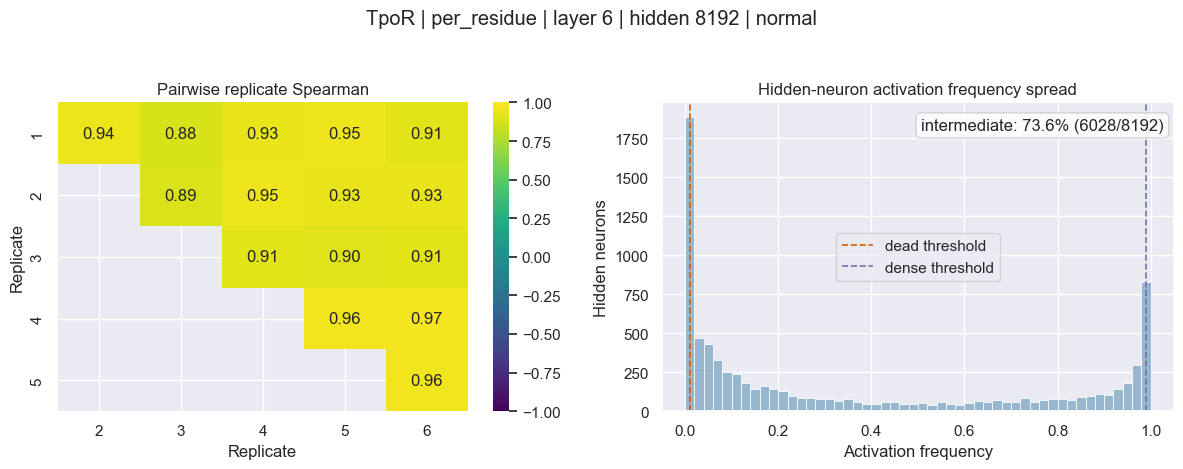

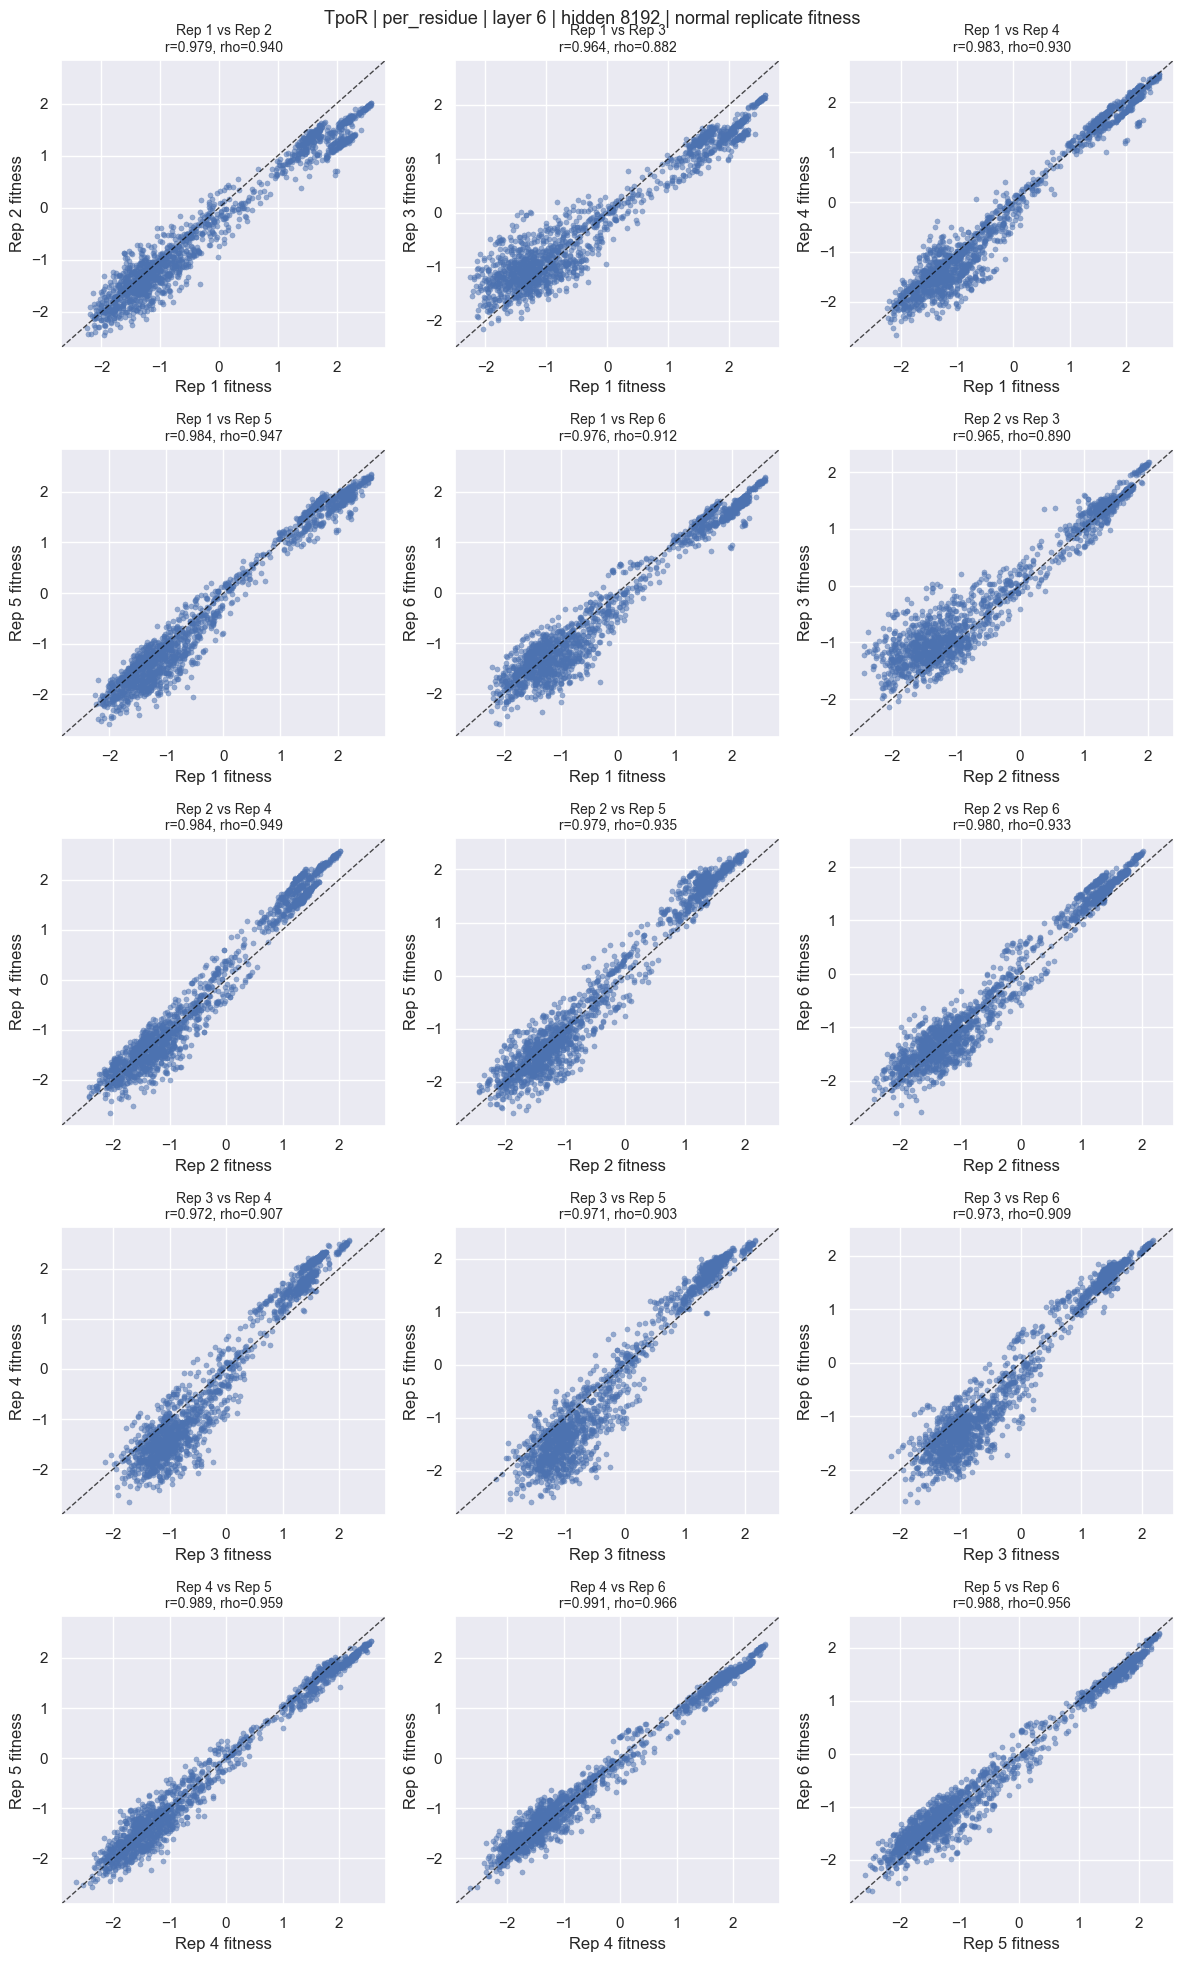

In [37]:
best_sae_row = sae_sweep_ranking.iloc[0]
best_dataset = best_sae_row["dataset"]
best_runner = runners[best_dataset]
best_layer = best_sae_row["layer"]
best_embedding_type = best_sae_row["embedding_type"]
best_method = best_sae_row.get("primary_seed_method", best_sae_row.get("method"))
best_k = None if pd.isna(best_sae_row["k"]) else int(best_sae_row["k"])
best_seed = int(best_sae_row.get("primary_seed", SAE_SWEEP_PRIMARY_SEED))
best_params = sae_sweep_params(
    int(best_sae_row["n_features"]),
    best_sae_row["sparsity_mode"],
    best_k,
    best_seed,
)

best_result = best_runner.load_inference_results(
    layer=best_layer,
    abstraction_method=best_method,
    norm_scheme=NORM_SCHEME,
    embedding_type=best_embedding_type,
)
seq_ids, best_features = best_runner._features_for_inference(
    best_layer,
    best_method,
    best_embedding_type,
    NORM_SCHEME,
    best_params,
)
best_rep_fitness = np.asarray([
    best_features @ best_result.s[rep_idx]
    for rep_idx in range(best_result.s.shape[0])
])
best_joint_fitness = best_features @ best_result.s_joint

best_pair_rows = []
for rep_i, rep_j in best_runner._rep_pairs(best_rep_fitness.shape[0]):
    best_pair_rows.append({
        "dataset": best_dataset,
        "embedding_type": best_embedding_type,
        "layer": best_layer,
        "n_features": int(best_sae_row["n_features"]),
        "sae_type": best_sae_row["sae_type"],
        "rep_i": rep_i + 1,
        "rep_j": rep_j + 1,
        "pearson_r": best_runner._safe_corr(best_rep_fitness[rep_i], best_rep_fitness[rep_j], pearsonr),
        "spearman_rho": best_runner._safe_corr(best_rep_fitness[rep_i], best_rep_fitness[rep_j], spearmanr),
        "n_variants": best_rep_fitness.shape[1],
    })

best_pair_summary = pd.DataFrame(best_pair_rows)
display(best_pair_summary.sort_values("spearman_rho", ascending=False))

best_rep_summary = pd.DataFrame({
    "replicate": np.arange(1, best_rep_fitness.shape[0] + 1),
    "fitness_mean": best_rep_fitness.mean(axis=1),
    "fitness_std": best_rep_fitness.std(axis=1),
    "fitness_min": best_rep_fitness.min(axis=1),
    "fitness_max": best_rep_fitness.max(axis=1),
    "selection_l2_norm": np.linalg.norm(best_result.s, axis=1),
    "selection_nonzero_fraction": (np.abs(best_result.s) > 1e-8).mean(axis=1),
})
display(best_rep_summary)

best_model_label = (
    f"{best_dataset} | {best_embedding_type} | layer {best_layer} | "
    f"hidden {int(best_sae_row['n_features'])} | {best_sae_row['sae_type']}"
)

best_viz = best_runner._load_pickle(sae_sweep_viz_path(best_runner, best_layer, best_embedding_type, best_params))
best_activation_frequency = (best_viz["Z_all"] > 0).mean(axis=0)
best_intermediate_mask = (
    (best_activation_frequency > SAE_SWEEP_DEAD_FREQUENCY_MAX)
    & (best_activation_frequency < SAE_SWEEP_DENSE_FREQUENCY_MIN)
)
best_intermediate_count = int(best_intermediate_mask.sum())
best_intermediate_pct = 100 * best_intermediate_count / len(best_activation_frequency)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(
    best_pair_summary.pivot(index="rep_i", columns="rep_j", values="spearman_rho"),
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title("Pairwise replicate Spearman")
axes[0].set_xlabel("Replicate")
axes[0].set_ylabel("Replicate")

sns.histplot(best_activation_frequency, bins=50, ax=axes[1], color="#7aa6c2")
axes[1].axvline(SAE_SWEEP_DEAD_FREQUENCY_MAX, color="#d95f02", linestyle="--", linewidth=1.2, label="dead threshold")
axes[1].axvline(SAE_SWEEP_DENSE_FREQUENCY_MIN, color="#7570b3", linestyle="--", linewidth=1.2, label="dense threshold")
axes[1].set_title("Hidden-neuron activation frequency spread")
axes[1].text(
    0.98,
    0.95,
    f"intermediate: {best_intermediate_pct:.1f}% ({best_intermediate_count}/{len(best_activation_frequency)})",
    transform=axes[1].transAxes,
    ha="right",
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
)
axes[1].set_xlabel("Activation frequency")
axes[1].set_ylabel("Hidden neurons")
axes[1].legend()

fig.suptitle(best_model_label, y=1.04)
fig.tight_layout()
display(fig)
plt.close(fig)

best_scatter_fig = best_runner._plot_rep_scatter_grid(
    best_rep_fitness,
    f"{best_model_label} replicate fitness",
    "fitness",
    output_path=None,
    max_cols=3,
)
display(best_scatter_fig)
plt.close(best_scatter_fig)
